In [6]:
# Jupyter-ready snippet to map patch coordinates between 2.5x and 5x

import os, re, glob, math
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict
import pandas as pd
from pathlib import PureWindowsPath

# -----------------------------
# 1) Config (EDIT THESE)
# -----------------------------
ROOT_2P5 = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x"
ROOT_5X  = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x"
ROOT_10X = r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x"

# If you know the grid stride at each scale (in pixels AT THAT SCALE), set it here:
STRIDE_2P5 = 224
STRIDE_5X  = 224

# Choose direction:
SRC_SCALE = 2.5   # mapping FROM this scale
DST_SCALE = 5.0   # mapping TO this scale

# Filenames look like: patch_0_x2464_y0.npy
PATCH_NAME_RE = re.compile(r"patch_(?P<idx>\d+)_x(?P<x>\d+)_y(?P<y>\d+)\.npy$", re.IGNORECASE)

@dataclass
class PatchRef:
    full_path: str
    scale_dir: str       # "2.5x" or "5x"
    base_scan_mag: str   # e.g., "20x"
    cls: str             # "FA" or "PT"
    slide_id: str        # e.g., "FA 56B"
    x: int
    y: int
    idx: int

def parse_patch_path(path: str) -> Optional[PatchRef]:
    """
    Parse a path like:
      C:\...\patches_2.5x\20x\FA\FA 56B\patch_0_x2464_y0.npy
    """
    p = PureWindowsPath(path)
    m = PATCH_NAME_RE.search(p.name)
    if not m:
        return None
    try:
        # parents[0]=slide_id, [1]=class, [2]=20x, [3]=patches_<scale>
        scale_dir     = p.parents[3].name.split("patches_")[-1]  # "2.5x" or "5x"
        base_scan_mag = p.parents[2].name                        # "20x"
        cls           = p.parents[1].name                        # "FA" or "PT"
        slide_id      = p.parents[0].name                        # e.g., "FA 56B"
    except Exception:
        return None

    return PatchRef(
        full_path=str(p),
        scale_dir=scale_dir,
        base_scan_mag=base_scan_mag,
        cls=cls,
        slide_id=slide_id,
        x=int(m.group("x")),
        y=int(m.group("y")),
        idx=int(m.group("idx"))
    )

def scale_coords(x: float, y: float, src_scale: float, dst_scale: float) -> Tuple[float, float]:
    r = dst_scale / src_scale
    return x * r, y * r

def snap_to_grid(val: float, stride: Optional[int]) -> int:
    if stride is None or stride <= 0:
        return int(round(val))
    return int(round(val / stride) * stride)

def list_patch_coords_for_slide(root: str, cls_: str, slide_id: str) -> List[Tuple[int, int, str]]:
    slide_dir = os.path.join(root, cls_, slide_id)
    files = glob.glob(os.path.join(slide_dir, "patch_*_x*_y*.npy"))
    out = []
    for f in files:
        pr = parse_patch_path(f)
        if pr is not None:
            out.append((pr.x, pr.y, pr.full_path))
    return out

def find_nearest_patch(dst_root: str, cls_: str, slide_id: str, x_target: int, y_target: int):
    """
    Returns (x_found, y_found, path, L1_distance) for the nearest patch in the destination slide.
    """
    coords = list_patch_coords_for_slide(dst_root, cls_, slide_id)
    if not coords:
        return None
    dists = [(abs(x - x_target) + abs(y - y_target), x, y, path) for (x, y, path) in coords]
    dists.sort(key=lambda t: t[0])
    best = dists[0]
    return best[1], best[2], best[3], best[0]

def map_one_patch(src_path: str,
                  dst_root: str,
                  src_scale: float,
                  dst_scale: float,
                  stride_dst: Optional[int] = None,
                  search_nearest: bool = True) -> Dict:
    """
    Map a source patch to destination scale, snap to grid, and optionally search the destination slide for the nearest file.
    """
    src = parse_patch_path(src_path)
    if src is None:
        raise ValueError(f"Could not parse patch path: {src_path}")

    # Predict destination coords
    x_pred_f, y_pred_f = scale_coords(src.x, src.y, src_scale, dst_scale)
    x_pred = snap_to_grid(x_pred_f, stride_dst)
    y_pred = snap_to_grid(y_pred_f, stride_dst)

    nearest = None
    if search_nearest:
        nearest = find_nearest_patch(dst_root, src.cls, src.slide_id, x_pred, y_pred)

    return {
        "src_path": src.full_path,
        "class": src.cls,
        "slide_id": src.slide_id,
        "src_scale": src_scale,
        "dst_scale": dst_scale,
        "src_x": src.x,
        "src_y": src.y,
        "x_pred_float": x_pred_f,
        "y_pred_float": y_pred_f,
        "x_pred_snapped": x_pred,
        "y_pred_snapped": y_pred,
        "nearest_dst_x": None if nearest is None else nearest[0],
        "nearest_dst_y": None if nearest is None else nearest[1],
        "nearest_dst_path": None if nearest is None else nearest[2],
        "nearest_L1_dist": None if nearest is None else nearest[3],
    }

def batch_map(src_root: str,
              dst_root: str,
              src_scale: float,
              dst_scale: float,
              cls_filter: Optional[str] = None,
              slide_filter: Optional[str] = None,
              stride_dst: Optional[int] = None,
              limit: Optional[int] = None) -> pd.DataFrame:
    """
    Build a mapping DataFrame for many patches at once.
    """
    classes = [cls_filter] if cls_filter else [d for d in os.listdir(src_root) if os.path.isdir(os.path.join(src_root, d))]
    rows = []
    for cls_ in classes:
        cls_dir = os.path.join(src_root, cls_)
        if not os.path.isdir(cls_dir):
            continue
        slides = [slide_filter] if slide_filter else [d for d in os.listdir(cls_dir) if os.path.isdir(os.path.join(cls_dir, d))]
        for slide_id in slides:
            slide_dir = os.path.join(cls_dir, slide_id)
            files = glob.glob(os.path.join(slide_dir, "patch_*_x*_y*.npy"))
            if limit is not None:
                files = files[:limit]
            for f in files:
                try:
                    rows.append(
                        map_one_patch(
                            src_path=f,
                            dst_root=dst_root,
                            src_scale=src_scale,
                            dst_scale=dst_scale,
                            stride_dst=stride_dst,
                            search_nearest=True
                        )
                    )
                except Exception as e:
                    rows.append({"src_path": f, "error": str(e)})
    return pd.DataFrame(rows)

# -----------------------------
# 2) Demo with your example file (parsing + numeric mapping)
# -----------------------------
example_2p5 = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 56B\patch_0_x2464_y0.npy"
demo = map_one_patch(
    src_path=example_2p5,
    dst_root=ROOT_5X,
    src_scale=SRC_SCALE,
    dst_scale=DST_SCALE,
    stride_dst=STRIDE_5X,
    search_nearest=False  # set True on your machine to find the nearest actual file in the 5x folder
)
demo


{'src_path': 'C:\\Users\\Vivian\\Documents\\CONCH\\all_patches\\patches_2.5x\\20x\\FA\\FA 56B\\patch_0_x2464_y0.npy',
 'class': 'FA',
 'slide_id': 'FA 56B',
 'src_scale': 2.5,
 'dst_scale': 5.0,
 'src_x': 2464,
 'src_y': 0,
 'x_pred_float': 4928.0,
 'y_pred_float': 0.0,
 'x_pred_snapped': 4928,
 'y_pred_snapped': 0,
 'nearest_dst_x': None,
 'nearest_dst_y': None,
 'nearest_dst_path': None,
 'nearest_L1_dist': None}

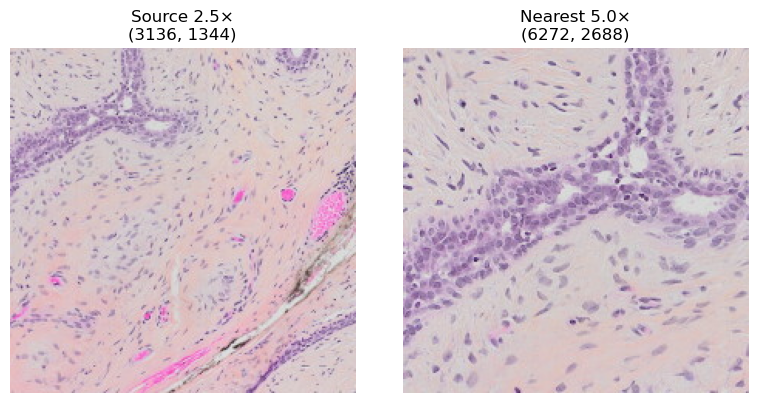

{'src_path': 'C:\\Users\\Vivian\\Documents\\CONCH\\all_patches\\patches_2.5x\\20x\\FA\\FA 56B\\patch_0_x2464_y0.npy',
 'class': 'FA',
 'slide_id': 'FA 56B',
 'src_scale': 2.5,
 'dst_scale': 10.0,
 'src_x': 2464,
 'src_y': 0,
 'x_pred_float': 9856.0,
 'y_pred_float': 0.0,
 'x_pred_snapped': 9856,
 'y_pred_snapped': 0,
 'nearest_dst_x': 9632,
 'nearest_dst_y': 448,
 'nearest_dst_path': 'C:\\Users\\Vivian\\Documents\\CONCH\\patches_tiled\\patches_10x\\20x\\FA\\FA 56B\\patch_1_x9632_y448.npy',
 'nearest_L1_dist': 672}

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from typing import Optional


def show_patch_pair(src_path: str,
                    dst_root: str,
                    src_scale: float,
                    dst_scale: float,
                    stride_dst: Optional[int] = None):
    """
    Map a patch from one scale to another and visualize both side-by-side.
    """
    mapping = map_one_patch(
        src_path=src_path,
        dst_root=dst_root,
        src_scale=src_scale,
        dst_scale=dst_scale,
        stride_dst=stride_dst,
        search_nearest=True
    )

    src_patch = np.load(mapping["src_path"])
    dst_patch = None

    if mapping["nearest_dst_path"] and os.path.exists(mapping["nearest_dst_path"]):
        dst_patch = np.load(mapping["nearest_dst_path"])

    # Convert to PIL for consistent display (some .npy patches may be float)
    def to_img(arr):
        if arr.ndim == 2:
            arr = np.stack([arr]*3, -1)
        if arr.dtype != np.uint8:
            arr = (255 * (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)).astype(np.uint8)
        return Image.fromarray(arr)

    src_img = to_img(src_patch)
    dst_img = to_img(dst_patch) if dst_patch is not None else None

    # --- Plot ---
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(src_img)
    plt.axis("off")
    plt.title(f"Source {src_scale}×\n({mapping['src_x']}, {mapping['src_y']})")

    plt.subplot(1, 2, 2)
    if dst_img is not None:
        plt.imshow(dst_img)
        plt.axis("off")
        plt.title(f"Nearest {dst_scale}×\n({mapping['nearest_dst_x']}, {mapping['nearest_dst_y']})")
    else:
        plt.text(0.5, 0.5, "No patch found", ha="center", va="center", fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return mapping

# --- Example usage ---
# example_2p5 = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 56B\patch_0_x2464_y0.npy"
example_2p5 = r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\PT\PT 40 B\patch_57_x3136_y1344.npy'
mapping_info = show_patch_pair(example_2p5, ROOT_5X, 2.5, 5.0, stride_dst=224)

example_2p5 = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 56B\patch_0_x2464_y0.npy"




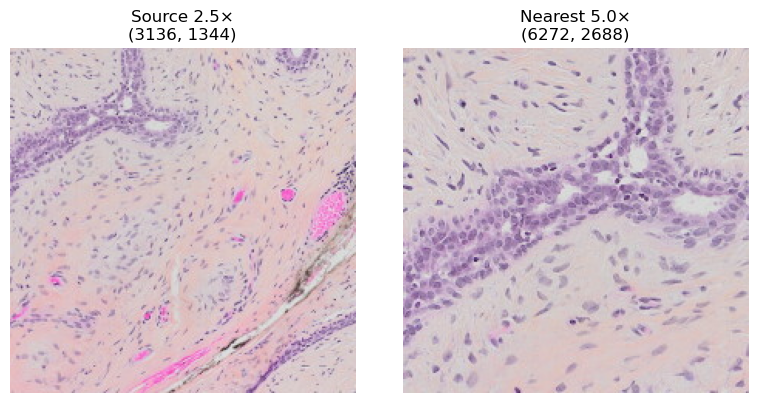

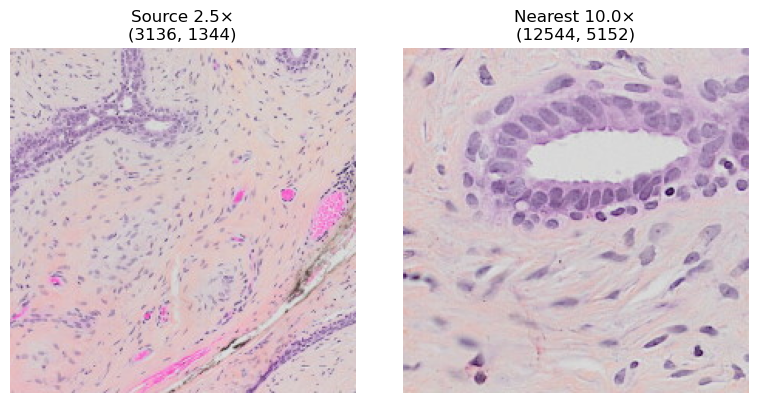

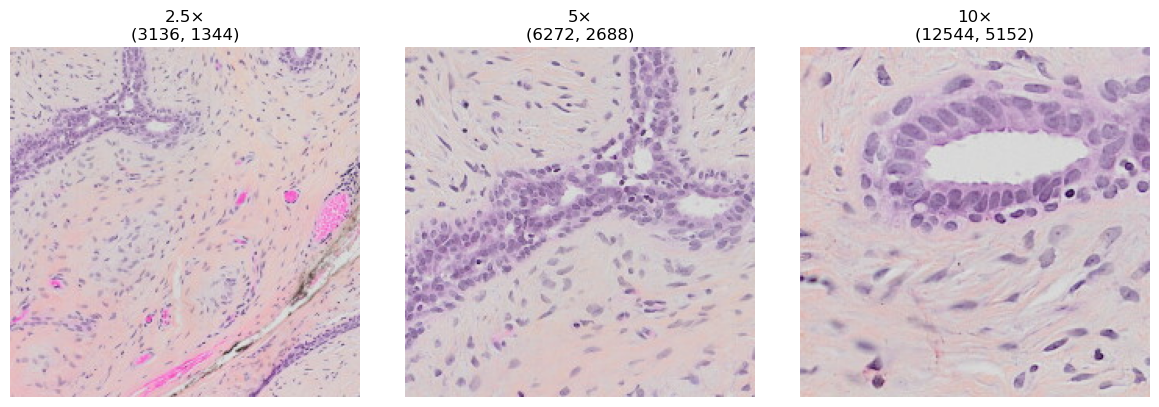

{'to_5x': {'src_path': 'C:\\Users\\Vivian\\Documents\\CONCH\\all_patches\\patches_2.5x\\20x\\PT\\PT 40 B\\patch_57_x3136_y1344.npy',
  'class': 'PT',
  'slide_id': 'PT 40 B',
  'src_scale': 2.5,
  'dst_scale': 5.0,
  'src_x': 3136,
  'src_y': 1344,
  'x_pred_float': 6272.0,
  'y_pred_float': 2688.0,
  'x_pred_snapped': 6272,
  'y_pred_snapped': 2688,
  'nearest_dst_x': 6272,
  'nearest_dst_y': 2688,
  'nearest_dst_path': 'C:\\Users\\Vivian\\Documents\\CONCH\\all_patches\\patches_5x\\20x\\PT\\PT 40 B\\patch_200_x6272_y2688.npy',
  'nearest_L1_dist': 0},
 'to_10x': {'src_path': 'C:\\Users\\Vivian\\Documents\\CONCH\\all_patches\\patches_2.5x\\20x\\PT\\PT 40 B\\patch_57_x3136_y1344.npy',
  'class': 'PT',
  'slide_id': 'PT 40 B',
  'src_scale': 2.5,
  'dst_scale': 10.0,
  'src_x': 3136,
  'src_y': 1344,
  'x_pred_float': 12544.0,
  'y_pred_float': 5376.0,
  'x_pred_snapped': 12544,
  'y_pred_snapped': 5376,
  'nearest_dst_x': 12544,
  'nearest_dst_y': 5152,
  'nearest_dst_path': 'C:\\Users\

In [11]:
# === Map patch coordinates between 2.5×, 5×, and 10×, with visualization ===

import os, re, glob, math
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import PureWindowsPath

# -----------------------------
# 1) Config (EDIT THESE)
# -----------------------------
ROOT_2P5 = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x"
ROOT_5X  = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x"
ROOT_10X = r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x"

# Per-scale strides (in pixels at that scale). If unknown, leave as 224 or None.
STRIDE_2P5 = 224
STRIDE_5X  = 224
STRIDE_10X = 224

# Convenience dicts
ROOTS   = {2.5: ROOT_2P5, 5.0: ROOT_5X, 10.0: ROOT_10X}
STRIDES = {2.5: STRIDE_2P5, 5.0: STRIDE_5X, 10.0: STRIDE_10X}

# Filenames look like: patch_0_x2464_y0.npy
PATCH_NAME_RE = re.compile(r"patch_(?P<idx>\d+)_x(?P<x>\d+)_y(?P<y>\d+)\.npy$", re.IGNORECASE)

@dataclass
class PatchRef:
    full_path: str
    scale_dir: str       # e.g., "2.5x", "5x", "10x"
    base_scan_mag: str   # e.g., "20x"
    cls: str             # "FA" or "PT"
    slide_id: str        # e.g., "FA 56B"
    x: int
    y: int
    idx: int

def parse_patch_path(path: str) -> Optional[PatchRef]:
    """
    Parse a path like:
      ...\patches_2.5x\20x\FA\FA 56B\patch_0_x2464_y0.npy
      ...\patches_10x\20x\FA\FA 56B\patch_0_x9856_y0.npy
    """
    p = PureWindowsPath(path)
    m = PATCH_NAME_RE.search(p.name)
    if not m:
        return None
    try:
        # parents[0]=slide_id, [1]=class, [2]=20x, [3]=patches_<scale>
        scale_dir     = p.parents[3].name.split("patches_")[-1]
        base_scan_mag = p.parents[2].name
        cls           = p.parents[1].name
        slide_id      = p.parents[0].name
    except Exception:
        return None

    return PatchRef(
        full_path=str(p),
        scale_dir=scale_dir,
        base_scan_mag=base_scan_mag,
        cls=cls,
        slide_id=slide_id,
        x=int(m.group("x")),
        y=int(m.group("y")),
        idx=int(m.group("idx"))
    )

def scale_coords(x: float, y: float, src_scale: float, dst_scale: float) -> Tuple[float, float]:
    """Convert coords between magnifications. Example: 2.5× -> 10× multiplies by 10/2.5 = 4."""
    r = dst_scale / src_scale
    return x * r, y * r

def snap_to_grid(val: float, stride: Optional[int]) -> int:
    """Snap to nearest multiple of stride (if given)."""
    if stride is None or stride <= 0:
        return int(round(val))
    return int(round(val / stride) * stride)

def list_patch_coords_for_slide(root: str, cls_: str, slide_id: str) -> List[Tuple[int, int, str]]:
    slide_dir = os.path.join(root, cls_, slide_id)
    files = glob.glob(os.path.join(slide_dir, "patch_*_x*_y*.npy"))
    out = []
    for f in files:
        pr = parse_patch_path(f)
        if pr is not None:
            out.append((pr.x, pr.y, pr.full_path))
    return out

def find_nearest_patch(dst_root: str, cls_: str, slide_id: str, x_target: int, y_target: int):
    """Return (x_found, y_found, path, L1_distance) for nearest patch in destination slide."""
    coords = list_patch_coords_for_slide(dst_root, cls_, slide_id)
    if not coords:
        return None
    dists = [(abs(x - x_target) + abs(y - y_target), x, y, path) for (x, y, path) in coords]
    dists.sort(key=lambda t: t[0])
    best = dists[0]
    return best[1], best[2], best[3], best[0]

def map_one_patch(src_path: str,
                  dst_root: str,
                  src_scale: float,
                  dst_scale: float,
                  stride_dst: Optional[int] = None,
                  search_nearest: bool = True) -> Dict:
    """Map a source patch to destination scale and optionally locate the nearest actual file."""
    src = parse_patch_path(src_path)
    if src is None:
        raise ValueError(f"Could not parse patch path: {src_path}")

    x_pred_f, y_pred_f = scale_coords(src.x, src.y, src_scale, dst_scale)
    x_pred = snap_to_grid(x_pred_f, stride_dst)
    y_pred = snap_to_grid(y_pred_f, stride_dst)

    nearest = None
    if search_nearest:
        nearest = find_nearest_patch(dst_root, src.cls, src.slide_id, x_pred, y_pred)

    return {
        "src_path": src.full_path,
        "class": src.cls,
        "slide_id": src.slide_id,
        "src_scale": src_scale,
        "dst_scale": dst_scale,
        "src_x": src.x,
        "src_y": src.y,
        "x_pred_float": x_pred_f,
        "y_pred_float": y_pred_f,
        "x_pred_snapped": x_pred,
        "y_pred_snapped": y_pred,
        "nearest_dst_x": None if nearest is None else nearest[0],
        "nearest_dst_y": None if nearest is None else nearest[1],
        "nearest_dst_path": None if nearest is None else nearest[2],
        "nearest_L1_dist": None if nearest is None else nearest[3],
    }

def batch_map(src_root: str,
              dst_root: str,
              src_scale: float,
              dst_scale: float,
              cls_filter: Optional[str] = None,
              slide_filter: Optional[str] = None,
              stride_dst: Optional[int] = None,
              limit: Optional[int] = None) -> pd.DataFrame:
    """Build a mapping DataFrame for many patches."""
    classes = [cls_filter] if cls_filter else [d for d in os.listdir(src_root) if os.path.isdir(os.path.join(src_root, d))]
    rows = []
    for cls_ in classes:
        cls_dir = os.path.join(src_root, cls_)
        if not os.path.isdir(cls_dir):
            continue
        slides = [slide_filter] if slide_filter else [d for d in os.listdir(cls_dir) if os.path.isdir(os.path.join(cls_dir, d))]
        for slide_id in slides:
            slide_dir = os.path.join(cls_dir, slide_id)
            files = glob.glob(os.path.join(slide_dir, "patch_*_x*_y*.npy"))
            if limit is not None:
                files = files[:limit]
            for f in files:
                try:
                    rows.append(
                        map_one_patch(
                            src_path=f,
                            dst_root=dst_root,
                            src_scale=src_scale,
                            dst_scale=dst_scale,
                            stride_dst=stride_dst,
                            search_nearest=True
                        )
                    )
                except Exception as e:
                    rows.append({"src_path": f, "error": str(e)})
    return pd.DataFrame(rows)

# -----------------------------
# 2) Visualization helpers
# -----------------------------
def _to_img(arr: np.ndarray) -> Image.Image:
    if arr.ndim == 2:
        arr = np.stack([arr]*3, -1)
    if arr.dtype != np.uint8:
        arr = (255 * (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)).astype(np.uint8)
    return Image.fromarray(arr)

def show_patch_pair(src_path: str,
                    dst_root: str,
                    src_scale: float,
                    dst_scale: float,
                    stride_dst: Optional[int] = None):
    """Side-by-side display of a source patch and its nearest destination patch."""
    mapping = map_one_patch(
        src_path=src_path,
        dst_root=dst_root,
        src_scale=src_scale,
        dst_scale=dst_scale,
        stride_dst=stride_dst,
        search_nearest=True
    )

    src_patch = np.load(mapping["src_path"])
    dst_patch = None
    if mapping["nearest_dst_path"] and os.path.exists(mapping["nearest_dst_path"]):
        dst_patch = np.load(mapping["nearest_dst_path"])

    src_img = _to_img(src_patch)
    dst_img = _to_img(dst_patch) if dst_patch is not None else None

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(src_img); plt.axis("off")
    plt.title(f"Source {src_scale}×\n({mapping['src_x']}, {mapping['src_y']})")

    plt.subplot(1, 2, 2)
    if dst_img is not None:
        plt.imshow(dst_img); plt.axis("off")
        plt.title(f"Nearest {dst_scale}×\n({mapping['nearest_dst_x']}, {mapping['nearest_dst_y']})")
    else:
        plt.text(0.5, 0.5, "No patch found", ha="center", va="center", fontsize=12); plt.axis("off")

    plt.tight_layout(); plt.show()
    return mapping

def show_patch_triplet(src_2p5_path: str,
                       dst5_root: str,
                       dst10_root: str,
                       stride5: Optional[int] = None,
                       stride10: Optional[int] = None):
    """Show a 2.5× patch with its nearest 5× and 10× counterparts."""
    m5  = map_one_patch(src_2p5_path, dst5_root, 2.5, 5.0, stride_dst=stride5, search_nearest=True)
    m10 = map_one_patch(src_2p5_path, dst10_root, 2.5, 10.0, stride_dst=stride10, search_nearest=True)

    src_patch = np.load(m5["src_path"])
    img_src = _to_img(src_patch)

    img_5 = None
    if m5["nearest_dst_path"] and os.path.exists(m5["nearest_dst_path"]):
        img_5 = _to_img(np.load(m5["nearest_dst_path"]))

    img_10 = None
    if m10["nearest_dst_path"] and os.path.exists(m10["nearest_dst_path"]):
        img_10 = _to_img(np.load(m10["nearest_dst_path"]))

    plt.figure(figsize=(12, 4))
    # 2.5×
    plt.subplot(1, 3, 1); plt.imshow(img_src); plt.axis("off")
    plt.title(f"2.5×\n({m5['src_x']}, {m5['src_y']})")
    # 5×
    plt.subplot(1, 3, 2)
    if img_5 is not None:
        plt.imshow(img_5); plt.axis("off")
        plt.title(f"5×\n({m5['nearest_dst_x']}, {m5['nearest_dst_y']})")
    else:
        plt.text(0.5, 0.5, "No 5× patch", ha="center", va="center"); plt.axis("off")
    # 10×
    plt.subplot(1, 3, 3)
    if img_10 is not None:
        plt.imshow(img_10); plt.axis("off")
        plt.title(f"10×\n({m10['nearest_dst_x']}, {m10['nearest_dst_y']})")
    else:
        plt.text(0.5, 0.5, "No 10× patch", ha="center", va="center"); plt.axis("off")

    plt.tight_layout(); plt.show()
    return {"to_5x": m5, "to_10x": m10}

# -----------------------------
# 3) Examples (uncomment and run)
# -----------------------------
# example_2p5 = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 56B\patch_0_x2464_y0.npy"
example_2p5 = r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\PT\PT 40 B\patch_57_x3136_y1344.npy'
show_patch_pair(example_2p5, ROOT_5X,  2.5, 5.0,  stride_dst=STRIDE_5X)
show_patch_pair(example_2p5, ROOT_10X, 2.5, 10.0, stride_dst=STRIDE_10X)
show_patch_triplet(example_2p5, ROOT_5X, ROOT_10X, stride5=STRIDE_5X, stride10=STRIDE_10X)


In [ ]:
# load a numpy file and display as image
def load_and_display_patch(path: str):
    arr = np.load(path)
    img = _to_img(arr)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # return mapping

load_and_display_patch(r"C:\\Users\\Vivian\\Documents\\CONCH\\all_patches\\patches_5x\\20x\\PT\\PT 40 B\\patch_200_x6272_y2688.npy")
load_and_display_patch(r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\PT\PT 40 B\patch_201_x6496_y2688.npy')
load_and_display_patch(r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x\PT\PT 40 B\patch_226_x6272_y2912.npy")

C:\Users\Vivian\AppData\Local\Temp\ipykernel_6860\2083586329.py:363: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


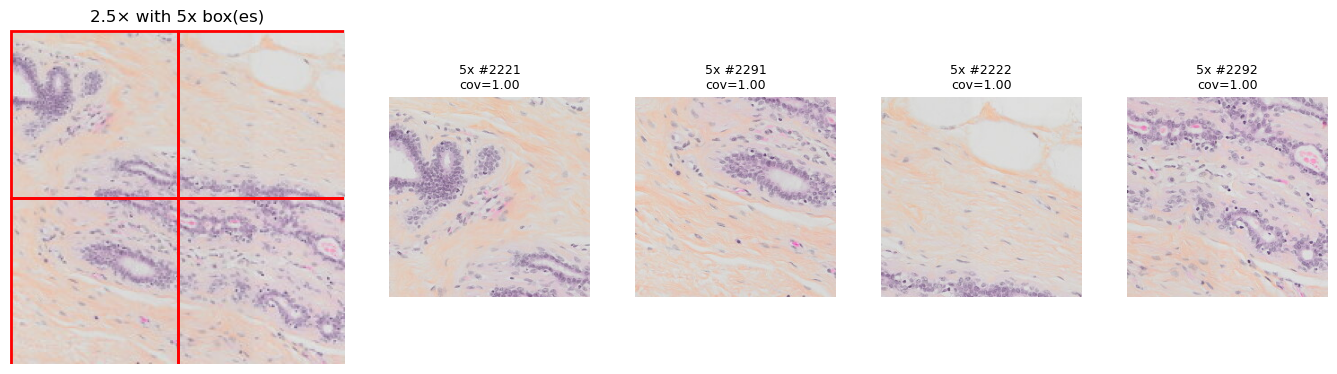

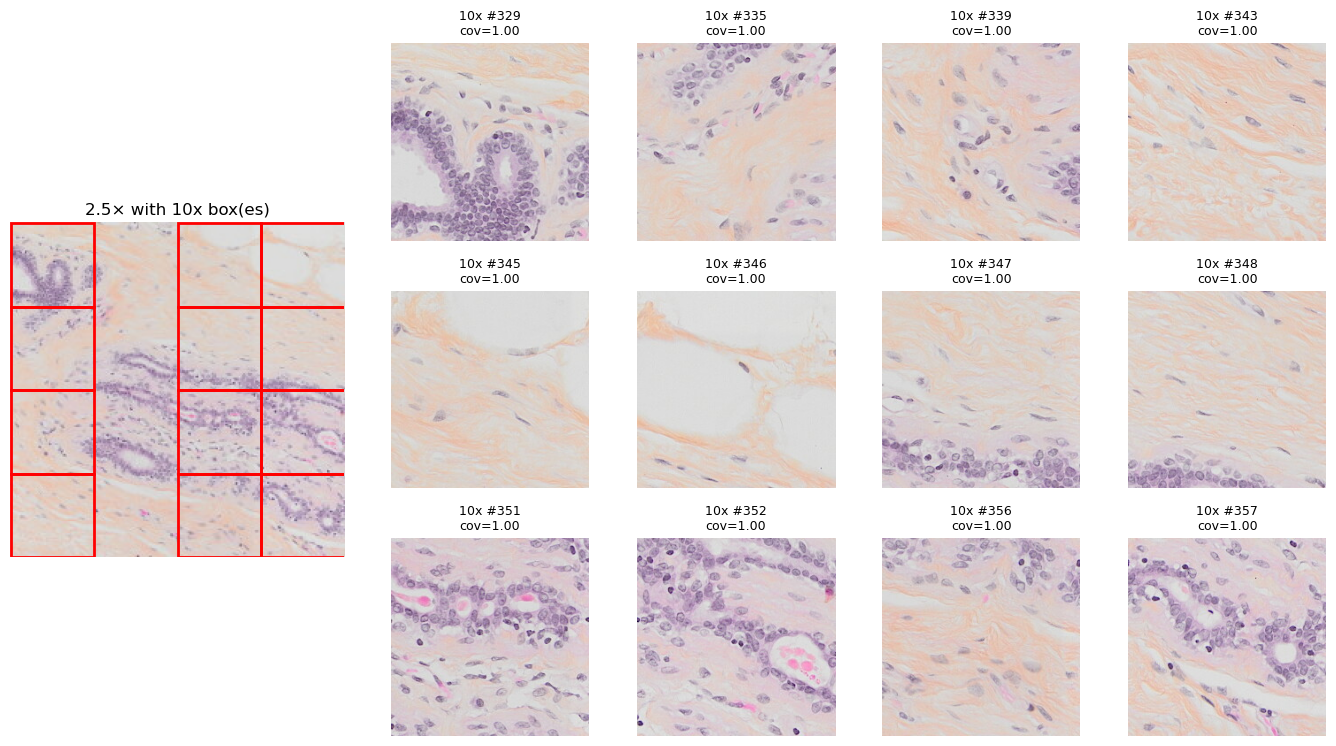

: 

In [ ]:
# === Multi-scale patch mapping & visualization (2.5×, 5×, 10×) with misalignment handling ===
# - Uses your existing path/filename conventions
# - Normalizes coordinates to Level-0 (full-resolution) for robust overlap-based mapping
# - Finds all 10× patches covering ≥ threshold of the 10× area for each 2.5× patch
# - Visual helpers: side-by-side and triplet views

import os, re, glob
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import PureWindowsPath
from collections import defaultdict

# -----------------------------
# 0) CONFIG — EDIT THESE
# -----------------------------
ROOT_2P5 = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x"
ROOT_5X  = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x"
ROOT_10X = r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x"

# Patch sizes at EACH scale (px at that scale)
PS_2P5 = 224
PS_5X  = 224
PS_10X = 224

# Downsample factors from EACH scale to Level-0 (full-res) in PX.
# If you used OpenSlide levels, replace with exact level_downsamples used for extraction.
# If not known, linear ratio by magnification is a reasonable start:
#   ds_2p5_to_L0 : ds_10x_to_L0 ≈ 10/2.5 = 4.0, and ds_5x_to_L0 ≈ 5/2.5 = 2.0
DS_2P5_TO_L0 = 4.0   # 2.5× coords * 4 -> Level-0 pixels (example)
DS_5X_TO_L0  = 2.0   # 5×   coords * 2 -> Level-0 pixels (example)
DS_10X_TO_L0 = 1.0   # 10×  coords * 1 -> Level-0 pixels (example)

# If your filenames carry stride implicitly, you can leave these as None.
# If you want to snap predicted coords to the destination grid, set strides accordingly.
STRIDE_2P5 = 224
STRIDE_5X  = 224
STRIDE_10X = 224

# Coverage threshold for mapping 10× to 2.5× (coverage of the 10× box)
COVERAGE_THRESH_10X = 0.70

# Optional spatial bucketing cell (Level-0 px) for speed on large slides
GRID_BIN_L0 = 2048

# Filename pattern: patch_XXX_x{X}_y{Y}.npy
PATCH_NAME_RE = re.compile(r"patch_(?P<idx>\d+)_x(?P<x>\d+)_y(?P<y>\d+)\.npy$", re.IGNORECASE)

# -----------------------------
# 1) Path parsing & listing (your logic, retained)
# -----------------------------
@dataclass
class PatchRef:
    full_path: str
    scale_dir: str       # "2.5x" / "5x" / "10x"
    base_scan_mag: str   # e.g., "20x"
    cls: str             # "FA" or "PT"
    slide_id: str        # e.g., "FA 56B"
    x: int
    y: int
    idx: int

def parse_patch_path(path: str) -> Optional[PatchRef]:
    """
    Parse a path like:
      ...\patches_2.5x\20x\FA\FA 56B\patch_0_x2464_y0.npy
      ...\patches_10x\20x\FA\FA 56B\patch_0_x9856_y0.npy
    """
    p = PureWindowsPath(path)
    m = PATCH_NAME_RE.search(p.name)
    if not m:
        return None
    try:
        # parents[0]=slide_id, [1]=class, [2]=20x, [3]=patches_<scale>
        scale_dir     = p.parents[3].name.split("patches_")[-1]
        base_scan_mag = p.parents[2].name
        cls           = p.parents[1].name
        slide_id      = p.parents[0].name
    except Exception:
        return None

    return PatchRef(
        full_path=str(p),
        scale_dir=scale_dir,
        base_scan_mag=base_scan_mag,
        cls=cls,
        slide_id=slide_id,
        x=int(m.group("x")),
        y=int(m.group("y")),
        idx=int(m.group("idx"))
    )

def list_patch_coords_for_slide(root: str, cls_: str, slide_id: str) -> List[Tuple[int, int, str]]:
    slide_dir = os.path.join(root, cls_, slide_id)
    files = glob.glob(os.path.join(slide_dir, "patch_*_x*_y*.npy"))
    out = []
    for f in files:
        pr = parse_patch_path(f)
        if pr is not None:
            out.append((pr.x, pr.y, pr.full_path))
    return out

# -----------------------------
# 2) Geometry in Level-0 space
# -----------------------------
import matplotlib.patches as mpatches

def _boxes_L0_to_2p5_local(boxes10_L0: np.ndarray,
                           idx_2: int,
                           boxes2_L0: np.ndarray,
                           coords2_2p5: np.ndarray) -> np.ndarray:
    """
    Convert 10× boxes in Level-0 to local coordinates inside a given 2.5× patch image.
    Returns (K,4) boxes in [x1,y1,x2,y2] in 2.5×-patch pixel space (0..PS_2P5), clipped.
    """
    # 10× boxes in 2.5× coordinates (global at 2.5× scale)
    boxes10_in_2p5 = boxes10_L0 / float(DS_2P5_TO_L0)

    # The selected 2.5× patch top-left in 2.5× space
    x2, y2 = coords2_2p5[idx_2]
    # Translate to local patch frame
    boxes_local = boxes10_in_2p5.copy()
    boxes_local[:, [0, 2]] -= x2
    boxes_local[:, [1, 3]] -= y2

    # Clip to the 2.5× patch extent [0, PS_2P5]
    boxes_local[:, 0] = np.clip(boxes_local[:, 0], 0, PS_2P5)
    boxes_local[:, 1] = np.clip(boxes_local[:, 1], 0, PS_2P5)
    boxes_local[:, 2] = np.clip(boxes_local[:, 2], 0, PS_2P5)
    boxes_local[:, 3] = np.clip(boxes_local[:, 3], 0, PS_2P5)

    # Remove degenerate boxes
    keep = (boxes_local[:, 2] > boxes_local[:, 0]) & (boxes_local[:, 3] > boxes_local[:, 1])
    return boxes_local[keep]


def boxes_from_coords(coords: np.ndarray, patch_size: int, downsample_to_L0: float) -> np.ndarray:
    """
    coords: (N,2) top-left in their own scale
    patch_size: int, in px at that scale
    downsample_to_L0: float, multiply to go to Level-0 px
    returns: (N,4) [x1,y1,x2,y2] in Level-0 px
    """
    tl = np.round(coords * downsample_to_L0).astype(np.int64)
    w  = int(round(patch_size * downsample_to_L0))
    x1, y1 = tl[:,0], tl[:,1]
    x2, y2 = x1 + w, y1 + w
    return np.stack([x1, y1, x2, y2], axis=1)

def intersection_area_xyxy(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """
    a: (M,4), b: (K,4) -> (M,K) intersection areas
    """
    ax1, ay1, ax2, ay2 = a[:,0,None], a[:,1,None], a[:,2,None], a[:,3,None]
    bx1, by1, bx2, by2 = b[None,:,0], b[None,:,1], b[None,:,2], b[None,:,3]
    ix1 = np.maximum(ax1, bx1)
    iy1 = np.maximum(ay1, by1)
    ix2 = np.minimum(ax2, bx2)
    iy2 = np.minimum(ay2, by2)
    iw  = np.clip(ix2 - ix1, 0, None)
    ih  = np.clip(iy2 - iy1, 0, None)
    return iw * ih

def bin_keys(boxes: np.ndarray, cell: int) -> np.ndarray:
    # Use box centers to assign bins in Level-0 pixel space
    cx = ((boxes[:,0] + boxes[:,2]) // 2) // cell
    cy = ((boxes[:,1] + boxes[:,3]) // 2) // cell
    return np.stack([cx, cy], 1)

from collections import defaultdict
COVERAGE_THRESH_5X = 0.70
def map_10x_to_2p5_for_slide(cls_: str,
                             slide_id: str,
                             coverage_thresh_10x: float = COVERAGE_THRESH_10X,
                             coverage_thresh_5x: float  = COVERAGE_THRESH_5X) -> Dict[str, object]:
    # Load coords for this slide
    c2  = list_patch_coords_for_slide(ROOT_2P5, cls_, slide_id)
    c10 = list_patch_coords_for_slide(ROOT_10X, cls_, slide_id)
    c5  = list_patch_coords_for_slide(ROOT_5X,  cls_, slide_id)

    if not c2:
        raise FileNotFoundError(f"No 2.5× patches for {cls_}/{slide_id}")

    coords2  = np.array([[x,y] for (x,y,_) in c2],  dtype=np.int64)
    coords10 = np.array([[x,y] for (x,y,_) in c10], dtype=np.int64) if c10 else np.zeros((0,2), dtype=np.int64)
    coords5  = np.array([[x,y] for (x,y,_) in c5],  dtype=np.int64) if c5  else np.zeros((0,2), dtype=np.int64)

    # Level-0 boxes
    boxes2  = boxes_from_coords(coords2,  PS_2P5, DS_2P5_TO_L0)
    boxes10 = boxes_from_coords(coords10, PS_10X, DS_10X_TO_L0)
    boxes5  = boxes_from_coords(coords5,  PS_5X,  DS_5X_TO_L0)

    # ----- Build spatial bins for speed -----
    def make_bin_index(boxes):
        key = bin_keys(boxes, GRID_BIN_L0) if len(boxes) else np.zeros((0,2))
        b2i = defaultdict(list)
        for i, k in enumerate(map(tuple, key)):
            b2i[k].append(i)
        return key, b2i

    key10, bin2idx10 = make_bin_index(boxes10)
    key5,  bin2idx5  = make_bin_index(boxes5)

    area10 = (boxes10[:,2]-boxes10[:,0]) * (boxes10[:,3]-boxes10[:,1]) if len(boxes10) else np.zeros(0)
    area5  = (boxes5[:,2]-boxes5[:,0])   * (boxes5[:,3]-boxes5[:,1])   if len(boxes5)  else np.zeros(0)

    neighbors = [(dx,dy) for dx in (-1,0,1) for dy in (-1,0,1)]
    key2 = bin_keys(boxes2, GRID_BIN_L0)

    # ----- Map 10× to each 2.5× -----
    map10_idx_per_2, cov10_per_2, best10_idx = [], [], []
    for i in range(boxes2.shape[0]):
        kx, ky = key2[i]
        cand = []
        for dx,dy in neighbors:
            cand.extend(bin2idx10.get((int(kx+dx), int(ky+dy)), []))
        cand = np.array(cand, dtype=int)
        if cand.size == 0:
            map10_idx_per_2.append(np.array([], dtype=int))
            cov10_per_2.append(np.array([], dtype=float))
            best10_idx.append(-1)
            continue
        inter = intersection_area_xyxy(boxes2[i:i+1], boxes10[cand])[0]
        cov   = inter / (area10[cand] + 1e-9)        # coverage of 10× by 2.5×
        keep  = np.where(cov >= coverage_thresh_10x)[0]
        kept  = cand[keep]
        map10_idx_per_2.append(kept)
        cov10_per_2.append(cov[keep])
        best10_idx.append(kept[np.argmax(cov[keep])] if keep.size else -1)

    # ----- Map 5× to each 2.5× (same idea) -----
    map5_idx_per_2, cov5_per_2, best5_idx = [], [], []
    for i in range(boxes2.shape[0]):
        kx, ky = key2[i]
        cand = []
        for dx,dy in neighbors:
            cand.extend(bin2idx5.get((int(kx+dx), int(ky+dy)), []))
        cand = np.array(cand, dtype=int)
        if cand.size == 0:
            map5_idx_per_2.append(np.array([], dtype=int))
            cov5_per_2.append(np.array([], dtype=float))
            best5_idx.append(-1)
            continue
        inter = intersection_area_xyxy(boxes2[i:i+1], boxes5[cand])[0]
        cov   = inter / (area5[cand] + 1e-9)         # coverage of 5× by 2.5×
        keep  = np.where(cov >= coverage_thresh_5x)[0]
        kept  = cand[keep]
        map5_idx_per_2.append(kept)
        cov5_per_2.append(cov[keep])
        best5_idx.append(kept[np.argmax(cov[keep])] if keep.size else -1)

    return {
        # 2.5×
        "coords2": coords2, "boxes2": boxes2, "paths2": [p for *_, p in c2],
        # 10× + mapping
        "coords10": coords10, "boxes10": boxes10, "paths10": [p for *_, p in c10],
        "map10_idx_per_2": map10_idx_per_2, "cov10_per_2": cov10_per_2, "best10_idx": np.array(best10_idx),
        # 5× + mapping
        "coords5": coords5, "boxes5": boxes5, "paths5": [p for *_, p in c5],
        "map5_idx_per_2": map5_idx_per_2, "cov5_per_2": cov5_per_2, "best5_idx": np.array(best5_idx),
    }
def show_2p5_with_boxes_and_patches(mapping,
                                    idx_2: int,
                                    target: str = "10x",   # "10x" or "5x"
                                    which: str = "all",    # "all" or "best"
                                    max_k: int = 8,
                                    sort_by_cov: bool = True,
                                    linewidth: float = 2.0):
    """
    Left: 2.5× patch with overlaid target-scale box(es).
    Right: matching target-scale patch(es) (best or top-k by coverage).
    """
    assert target in ("10x", "5x")
    path2 = mapping["paths2"][idx_2]
    img2  = _to_img(np.load(path2))

    # pick the right arrays
    if target == "10x":
        idx_all = mapping["map10_idx_per_2"][idx_2]
        cov_all = mapping["cov10_per_2"][idx_2]
        best    = mapping["best10_idx"][idx_2]
        boxesT  = mapping["boxes10"]
        pathsT  = mapping["paths10"]
    else:  # "5x"
        idx_all = mapping["map5_idx_per_2"][idx_2]
        cov_all = mapping["cov5_per_2"][idx_2]
        best    = mapping["best5_idx"][idx_2]
        boxesT  = mapping["boxes5"]
        pathsT  = mapping["paths5"]

    # select which to display
    if which == "best":
        sel_idx = np.array([best], dtype=int) if best >= 0 else np.array([], dtype=int)
        if sel_idx.size and len(idx_all):
            # find its coverage for the title
            pos = np.where(idx_all == best)[0]
            sel_cov = np.array([cov_all[pos[0]]]) if pos.size else np.array([1.0])
        else:
            sel_cov = np.array([])
    else:
        sel_idx = np.asarray(idx_all, dtype=int)
        sel_cov = np.asarray(cov_all, dtype=float)

    if sel_idx.size == 0:
        plt.figure(figsize=(5,5))
        plt.imshow(img2); plt.axis("off")
        plt.title(f"2.5× (no {target} matches ≥ threshold)")
        plt.tight_layout(); plt.show()
        return

    # order & clip
    if sort_by_cov and sel_idx.size > 1:
        order = np.argsort(-sel_cov)
        sel_idx, sel_cov = sel_idx[order], sel_cov[order]
    if which == "all" and sel_idx.size > max_k:
        sel_idx, sel_cov = sel_idx[:max_k], sel_cov[:max_k]

    # convert target boxes to local 2.5×-patch coords
    boxes_local = _boxes_L0_to_2p5_local(
        boxesT[sel_idx],
        idx_2,
        mapping["boxes2"],
        mapping["coords2"]
    )

    # build cov dict for overlay alpha
    cov_dict = {int(j): float(c) for j, c in zip(idx_all.tolist(), cov_all.tolist())}

    # figure layout: left + grid on right
    import math, matplotlib.gridspec as gridspec, matplotlib.patches as mpatches
    n_right = sel_idx.size
    ncols = 4 if which == "all" else 1
    nrows = math.ceil(n_right / ncols)
    fig = plt.figure(figsize=(5 + 3*ncols, max(5, 3*nrows)))
    gs = gridspec.GridSpec(nrows, ncols+1, width_ratios=[5] + [3]*ncols, wspace=0.2, hspace=0.25)

    # left: 2.5× with boxes
    ax_left = fig.add_subplot(gs[:, 0])
    ax_left.imshow(img2); ax_left.set_axis_off()
    ax_left.set_title(f"2.5× with {target} box(es)")
    for j, box in zip(sel_idx.tolist(), boxes_local):
        x1, y1, x2, y2 = box.tolist()
        if x2 <= x1 or y2 <= y1:  # skip empty
            continue
        cov = cov_dict.get(int(j), 1.0)
        ax_left.add_patch(
            mpatches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                               linewidth=linewidth, edgecolor="red",
                               alpha=0.5 + 0.5*min(max(cov,0.0),1.0))
        )

    # right: target patches
    for k in range(n_right):
        r = k // ncols; c = (k % ncols) + 1
        ax = fig.add_subplot(gs[r, c])
        imgT = _to_img(np.load(pathsT[int(sel_idx[k])]))
        ax.imshow(imgT); ax.set_axis_off()
        ax.set_title(f"{target} #{int(sel_idx[k])}\ncov={float(sel_cov[k]):.2f}", fontsize=9)

    plt.tight_layout(); plt.show()
# -----------------------------
# 5) Visualization helpers
# -----------------------------
def _to_img(arr: Optional[np.ndarray]) -> Image.Image:
    if arr is None:
        return None
    if arr.ndim == 2:
        arr = np.stack([arr]*3, -1)
    if arr.dtype != np.uint8:
        a = arr.astype(np.float32)
        a = (255 * (a - a.min()) / (a.max() - a.min() + 1e-8)).astype(np.uint8)
        arr = a
    return Image.fromarray(arr)
# -----------------------------
mapping = map_10x_to_2p5_for_slide("PT", "PT 39 B",
                                   coverage_thresh_10x=0.70,
                                   coverage_thresh_5x=0.70)

# 5×: best or all
show_2p5_with_boxes_and_patches(mapping, idx_2=56, target="5x", which="all", max_k=4)

# 10×: best or all
show_2p5_with_boxes_and_patches(mapping, idx_2=56, target="10x", which="all", max_k=16)


C:\Users\Vivian\AppData\Local\Temp\ipykernel_46424\3748828363.py:363: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


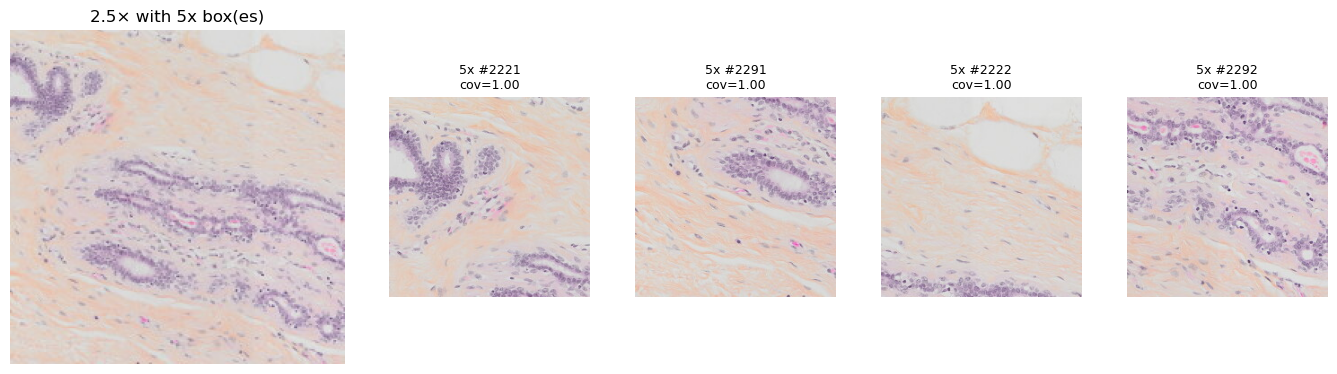

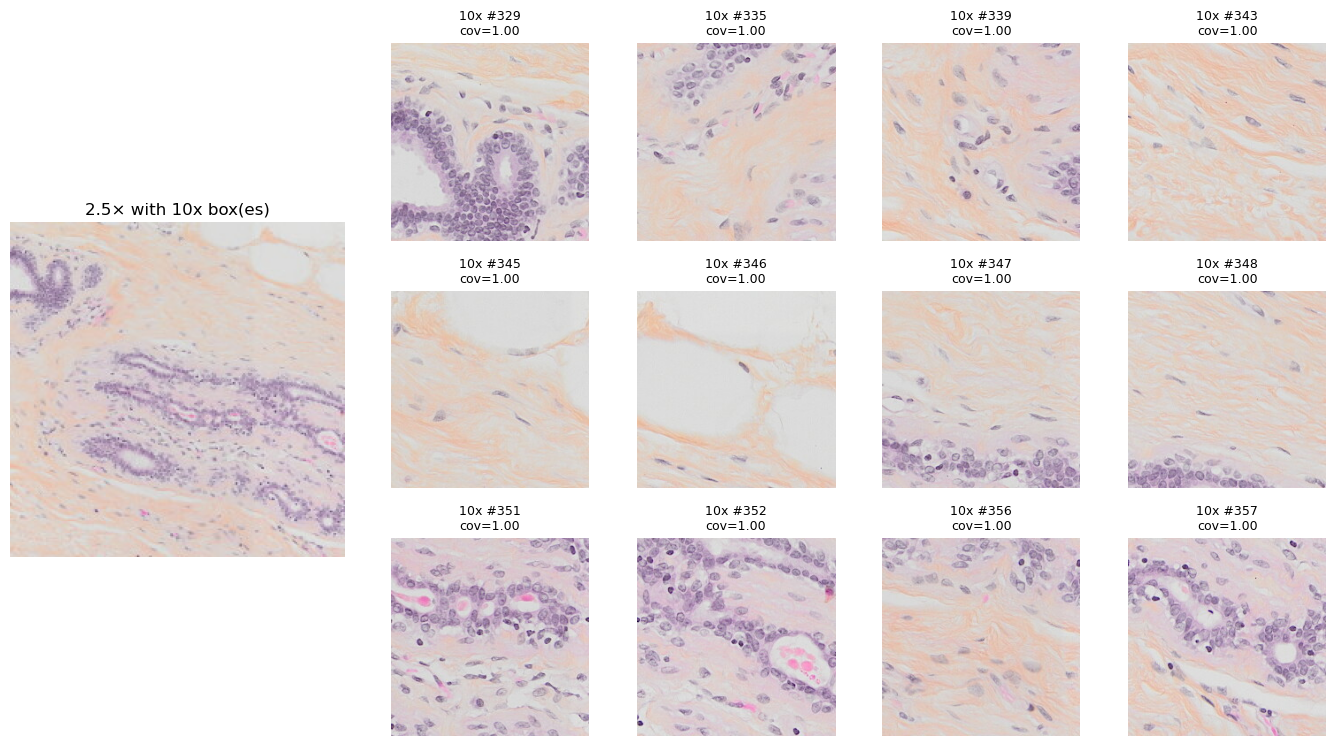

In [1]:
# === Multi-scale patch mapping & visualization (2.5×, 5×, 10×) with misalignment handling ===
# - Uses your existing path/filename conventions
# - Normalizes coordinates to Level-0 (full-resolution) for robust overlap-based mapping
# - Finds all 10× patches covering ≥ threshold of the 10× area for each 2.5× patch
# - Visual helpers: side-by-side and triplet views

import os, re, glob
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import PureWindowsPath
from collections import defaultdict

# -----------------------------
# 0) CONFIG — EDIT THESE
# -----------------------------
ROOT_2P5 = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x"
ROOT_5X  = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\20x"
ROOT_10X = r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x"

# Patch sizes at EACH scale (px at that scale)
PS_2P5 = 224
PS_5X  = 224
PS_10X = 224

# Downsample factors from EACH scale to Level-0 (full-res) in PX.
# If you used OpenSlide levels, replace with exact level_downsamples used for extraction.
# If not known, linear ratio by magnification is a reasonable start:
#   ds_2p5_to_L0 : ds_10x_to_L0 ≈ 10/2.5 = 4.0, and ds_5x_to_L0 ≈ 5/2.5 = 2.0
DS_2P5_TO_L0 = 4.0   # 2.5× coords * 4 -> Level-0 pixels (example)
DS_5X_TO_L0  = 2.0   # 5×   coords * 2 -> Level-0 pixels (example)
DS_10X_TO_L0 = 1.0   # 10×  coords * 1 -> Level-0 pixels (example)

# If your filenames carry stride implicitly, you can leave these as None.
# If you want to snap predicted coords to the destination grid, set strides accordingly.
STRIDE_2P5 = 224
STRIDE_5X  = 224
STRIDE_10X = 224

# Coverage threshold for mapping 10× to 2.5× (coverage of the 10× box)
COVERAGE_THRESH_10X = 0.70

# Optional spatial bucketing cell (Level-0 px) for speed on large slides
GRID_BIN_L0 = 2048

# Filename pattern: patch_XXX_x{X}_y{Y}.npy
PATCH_NAME_RE = re.compile(r"patch_(?P<idx>\d+)_x(?P<x>\d+)_y(?P<y>\d+)\.npy$", re.IGNORECASE)

# -----------------------------
# 1) Path parsing & listing (your logic, retained)
# -----------------------------
@dataclass
class PatchRef:
    full_path: str
    scale_dir: str       # "2.5x" / "5x" / "10x"
    base_scan_mag: str   # e.g., "20x"
    cls: str             # "FA" or "PT"
    slide_id: str        # e.g., "FA 56B"
    x: int
    y: int
    idx: int

def parse_patch_path(path: str) -> Optional[PatchRef]:
    """
    Parse a path like:
      ...\patches_2.5x\20x\FA\FA 56B\patch_0_x2464_y0.npy
      ...\patches_10x\20x\FA\FA 56B\patch_0_x9856_y0.npy
    """
    p = PureWindowsPath(path)
    m = PATCH_NAME_RE.search(p.name)
    if not m:
        return None
    try:
        # parents[0]=slide_id, [1]=class, [2]=20x, [3]=patches_<scale>
        scale_dir     = p.parents[3].name.split("patches_")[-1]
        base_scan_mag = p.parents[2].name
        cls           = p.parents[1].name
        slide_id      = p.parents[0].name
    except Exception:
        return None

    return PatchRef(
        full_path=str(p),
        scale_dir=scale_dir,
        base_scan_mag=base_scan_mag,
        cls=cls,
        slide_id=slide_id,
        x=int(m.group("x")),
        y=int(m.group("y")),
        idx=int(m.group("idx"))
    )

def list_patch_coords_for_slide(root: str, cls_: str, slide_id: str) -> List[Tuple[int, int, str]]:
    slide_dir = os.path.join(root, cls_, slide_id)
    files = glob.glob(os.path.join(slide_dir, "patch_*_x*_y*.npy"))
    out = []
    for f in files:
        pr = parse_patch_path(f)
        if pr is not None:
            out.append((pr.x, pr.y, pr.full_path))
    return out

# -----------------------------
# 2) Geometry in Level-0 space
# -----------------------------
import matplotlib.patches as mpatches

def _boxes_L0_to_2p5_local(boxes10_L0: np.ndarray,
                           idx_2: int,
                           boxes2_L0: np.ndarray,
                           coords2_2p5: np.ndarray) -> np.ndarray:
    """
    Convert 10× boxes in Level-0 to local coordinates inside a given 2.5× patch image.
    Returns (K,4) boxes in [x1,y1,x2,y2] in 2.5×-patch pixel space (0..PS_2P5), clipped.
    """
    # 10× boxes in 2.5× coordinates (global at 2.5× scale)
    boxes10_in_2p5 = boxes10_L0 / float(DS_2P5_TO_L0)

    # The selected 2.5× patch top-left in 2.5× space
    x2, y2 = coords2_2p5[idx_2]
    # Translate to local patch frame
    boxes_local = boxes10_in_2p5.copy()
    boxes_local[:, [0, 2]] -= x2
    boxes_local[:, [1, 3]] -= y2

    # Clip to the 2.5× patch extent [0, PS_2P5]
    boxes_local[:, 0] = np.clip(boxes_local[:, 0], 0, PS_2P5)
    boxes_local[:, 1] = np.clip(boxes_local[:, 1], 0, PS_2P5)
    boxes_local[:, 2] = np.clip(boxes_local[:, 2], 0, PS_2P5)
    boxes_local[:, 3] = np.clip(boxes_local[:, 3], 0, PS_2P5)

    # Remove degenerate boxes
    keep = (boxes_local[:, 2] > boxes_local[:, 0]) & (boxes_local[:, 3] > boxes_local[:, 1])
    return boxes_local[keep]


def boxes_from_coords(coords: np.ndarray, patch_size: int, downsample_to_L0: float) -> np.ndarray:
    """
    coords: (N,2) top-left in their own scale
    patch_size: int, in px at that scale
    downsample_to_L0: float, multiply to go to Level-0 px
    returns: (N,4) [x1,y1,x2,y2] in Level-0 px
    """
    tl = np.round(coords * downsample_to_L0).astype(np.int64)
    w  = int(round(patch_size * downsample_to_L0))
    x1, y1 = tl[:,0], tl[:,1]
    x2, y2 = x1 + w, y1 + w
    return np.stack([x1, y1, x2, y2], axis=1)

def intersection_area_xyxy(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """
    a: (M,4), b: (K,4) -> (M,K) intersection areas
    """
    ax1, ay1, ax2, ay2 = a[:,0,None], a[:,1,None], a[:,2,None], a[:,3,None]
    bx1, by1, bx2, by2 = b[None,:,0], b[None,:,1], b[None,:,2], b[None,:,3]
    ix1 = np.maximum(ax1, bx1)
    iy1 = np.maximum(ay1, by1)
    ix2 = np.minimum(ax2, bx2)
    iy2 = np.minimum(ay2, by2)
    iw  = np.clip(ix2 - ix1, 0, None)
    ih  = np.clip(iy2 - iy1, 0, None)
    return iw * ih

def bin_keys(boxes: np.ndarray, cell: int) -> np.ndarray:
    # Use box centers to assign bins in Level-0 pixel space
    cx = ((boxes[:,0] + boxes[:,2]) // 2) // cell
    cy = ((boxes[:,1] + boxes[:,3]) // 2) // cell
    return np.stack([cx, cy], 1)

from collections import defaultdict
COVERAGE_THRESH_5X = 0.70
def map_10x_to_2p5_for_slide(cls_: str,
                             slide_id: str,
                             coverage_thresh_10x: float = COVERAGE_THRESH_10X,
                             coverage_thresh_5x: float  = COVERAGE_THRESH_5X) -> Dict[str, object]:
    # Load coords for this slide
    c2  = list_patch_coords_for_slide(ROOT_2P5, cls_, slide_id)
    c10 = list_patch_coords_for_slide(ROOT_10X, cls_, slide_id)
    c5  = list_patch_coords_for_slide(ROOT_5X,  cls_, slide_id)

    if not c2:
        raise FileNotFoundError(f"No 2.5× patches for {cls_}/{slide_id}")

    coords2  = np.array([[x,y] for (x,y,_) in c2],  dtype=np.int64)
    coords10 = np.array([[x,y] for (x,y,_) in c10], dtype=np.int64) if c10 else np.zeros((0,2), dtype=np.int64)
    coords5  = np.array([[x,y] for (x,y,_) in c5],  dtype=np.int64) if c5  else np.zeros((0,2), dtype=np.int64)

    # Level-0 boxes
    boxes2  = boxes_from_coords(coords2,  PS_2P5, DS_2P5_TO_L0)
    boxes10 = boxes_from_coords(coords10, PS_10X, DS_10X_TO_L0)
    boxes5  = boxes_from_coords(coords5,  PS_5X,  DS_5X_TO_L0)

    # ----- Build spatial bins for speed -----
    def make_bin_index(boxes):
        key = bin_keys(boxes, GRID_BIN_L0) if len(boxes) else np.zeros((0,2))
        b2i = defaultdict(list)
        for i, k in enumerate(map(tuple, key)):
            b2i[k].append(i)
        return key, b2i

    key10, bin2idx10 = make_bin_index(boxes10)
    key5,  bin2idx5  = make_bin_index(boxes5)

    area10 = (boxes10[:,2]-boxes10[:,0]) * (boxes10[:,3]-boxes10[:,1]) if len(boxes10) else np.zeros(0)
    area5  = (boxes5[:,2]-boxes5[:,0])   * (boxes5[:,3]-boxes5[:,1])   if len(boxes5)  else np.zeros(0)

    neighbors = [(dx,dy) for dx in (-1,0,1) for dy in (-1,0,1)]
    key2 = bin_keys(boxes2, GRID_BIN_L0)

    # ----- Map 10× to each 2.5× -----
    map10_idx_per_2, cov10_per_2, best10_idx = [], [], []
    for i in range(boxes2.shape[0]):
        kx, ky = key2[i]
        cand = []
        for dx,dy in neighbors:
            cand.extend(bin2idx10.get((int(kx+dx), int(ky+dy)), []))
        cand = np.array(cand, dtype=int)
        if cand.size == 0:
            map10_idx_per_2.append(np.array([], dtype=int))
            cov10_per_2.append(np.array([], dtype=float))
            best10_idx.append(-1)
            continue
        inter = intersection_area_xyxy(boxes2[i:i+1], boxes10[cand])[0]
        cov   = inter / (area10[cand] + 1e-9)        # coverage of 10× by 2.5×
        keep  = np.where(cov >= coverage_thresh_10x)[0]
        kept  = cand[keep]
        map10_idx_per_2.append(kept)
        cov10_per_2.append(cov[keep])
        best10_idx.append(kept[np.argmax(cov[keep])] if keep.size else -1)

    # ----- Map 5× to each 2.5× (same idea) -----
    map5_idx_per_2, cov5_per_2, best5_idx = [], [], []
    for i in range(boxes2.shape[0]):
        kx, ky = key2[i]
        cand = []
        for dx,dy in neighbors:
            cand.extend(bin2idx5.get((int(kx+dx), int(ky+dy)), []))
        cand = np.array(cand, dtype=int)
        if cand.size == 0:
            map5_idx_per_2.append(np.array([], dtype=int))
            cov5_per_2.append(np.array([], dtype=float))
            best5_idx.append(-1)
            continue
        inter = intersection_area_xyxy(boxes2[i:i+1], boxes5[cand])[0]
        cov   = inter / (area5[cand] + 1e-9)         # coverage of 5× by 2.5×
        keep  = np.where(cov >= coverage_thresh_5x)[0]
        kept  = cand[keep]
        map5_idx_per_2.append(kept)
        cov5_per_2.append(cov[keep])
        best5_idx.append(kept[np.argmax(cov[keep])] if keep.size else -1)

    return {
        # 2.5×
        "coords2": coords2, "boxes2": boxes2, "paths2": [p for *_, p in c2],
        # 10× + mapping
        "coords10": coords10, "boxes10": boxes10, "paths10": [p for *_, p in c10],
        "map10_idx_per_2": map10_idx_per_2, "cov10_per_2": cov10_per_2, "best10_idx": np.array(best10_idx),
        # 5× + mapping
        "coords5": coords5, "boxes5": boxes5, "paths5": [p for *_, p in c5],
        "map5_idx_per_2": map5_idx_per_2, "cov5_per_2": cov5_per_2, "best5_idx": np.array(best5_idx),
    }
def show_2p5_with_boxes_and_patches(mapping,
                                    idx_2: int,
                                    target: str = "10x",   # "10x" or "5x"
                                    which: str = "all",    # "all" or "best"
                                    max_k: int = 8,
                                    sort_by_cov: bool = True,
                                    linewidth: float = 2.0):
    """
    Left: 2.5× patch with overlaid target-scale box(es).
    Right: matching target-scale patch(es) (best or top-k by coverage).
    """
    assert target in ("10x", "5x")
    path2 = mapping["paths2"][idx_2]
    img2  = _to_img(np.load(path2))

    # pick the right arrays
    if target == "10x":
        idx_all = mapping["map10_idx_per_2"][idx_2]
        cov_all = mapping["cov10_per_2"][idx_2]
        best    = mapping["best10_idx"][idx_2]
        boxesT  = mapping["boxes10"]
        pathsT  = mapping["paths10"]
    else:  # "5x"
        idx_all = mapping["map5_idx_per_2"][idx_2]
        cov_all = mapping["cov5_per_2"][idx_2]
        best    = mapping["best5_idx"][idx_2]
        boxesT  = mapping["boxes5"]
        pathsT  = mapping["paths5"]

    # select which to display
    if which == "best":
        sel_idx = np.array([best], dtype=int) if best >= 0 else np.array([], dtype=int)
        if sel_idx.size and len(idx_all):
            # find its coverage for the title
            pos = np.where(idx_all == best)[0]
            sel_cov = np.array([cov_all[pos[0]]]) if pos.size else np.array([1.0])
        else:
            sel_cov = np.array([])
    else:
        sel_idx = np.asarray(idx_all, dtype=int)
        sel_cov = np.asarray(cov_all, dtype=float)

    if sel_idx.size == 0:
        plt.figure(figsize=(5,5))
        plt.imshow(img2); plt.axis("off")
        plt.title(f"2.5× (no {target} matches ≥ threshold)")
        plt.tight_layout(); plt.show()
        return

    # order & clip
    if sort_by_cov and sel_idx.size > 1:
        order = np.argsort(-sel_cov)
        sel_idx, sel_cov = sel_idx[order], sel_cov[order]
    if which == "all" and sel_idx.size > max_k:
        sel_idx, sel_cov = sel_idx[:max_k], sel_cov[:max_k]

    # convert target boxes to local 2.5×-patch coords
    boxes_local = _boxes_L0_to_2p5_local(
        boxesT[sel_idx],
        idx_2,
        mapping["boxes2"],
        mapping["coords2"]
    )

    # build cov dict for overlay alpha
    cov_dict = {int(j): float(c) for j, c in zip(idx_all.tolist(), cov_all.tolist())}

    # figure layout: left + grid on right
    import math, matplotlib.gridspec as gridspec, matplotlib.patches as mpatches
    n_right = sel_idx.size
    ncols = 4 if which == "all" else 1
    nrows = math.ceil(n_right / ncols)
    fig = plt.figure(figsize=(5 + 3*ncols, max(5, 3*nrows)))
    gs = gridspec.GridSpec(nrows, ncols+1, width_ratios=[5] + [3]*ncols, wspace=0.2, hspace=0.25)

    # left: 2.5× with boxes
    ax_left = fig.add_subplot(gs[:, 0])
    ax_left.imshow(img2); ax_left.set_axis_off()
    ax_left.set_title(f"2.5× with {target} box(es)")
    # for j, box in zip(sel_idx.tolist(), boxes_local):
    #     x1, y1, x2, y2 = box.tolist()
    #     if x2 <= x1 or y2 <= y1:  # skip empty
    #         continue
    #     cov = cov_dict.get(int(j), 1.0)
    #     ax_left.add_patch(
    #         mpatches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
    #                            linewidth=linewidth, edgecolor="red",
    #                            alpha=0.5 + 0.5*min(max(cov,0.0),1.0))
    #     )

    # right: target patches
    for k in range(n_right):
        r = k // ncols; c = (k % ncols) + 1
        ax = fig.add_subplot(gs[r, c])
        imgT = _to_img(np.load(pathsT[int(sel_idx[k])]))
        ax.imshow(imgT); ax.set_axis_off()
        ax.set_title(f"{target} #{int(sel_idx[k])}\ncov={float(sel_cov[k]):.2f}", fontsize=9)

    plt.tight_layout(); plt.show()
# -----------------------------
# 5) Visualization helpers
# -----------------------------
def _to_img(arr: Optional[np.ndarray]) -> Image.Image:
    if arr is None:
        return None
    if arr.ndim == 2:
        arr = np.stack([arr]*3, -1)
    if arr.dtype != np.uint8:
        a = arr.astype(np.float32)
        a = (255 * (a - a.min()) / (a.max() - a.min() + 1e-8)).astype(np.uint8)
        arr = a
    return Image.fromarray(arr)
# -----------------------------
mapping = map_10x_to_2p5_for_slide("PT", "PT 39 B",
                                   coverage_thresh_10x=0.70,
                                   coverage_thresh_5x=0.70)

# 5×: best or all
show_2p5_with_boxes_and_patches(mapping, idx_2=56, target="5x", which="all", max_k=4)

# 10×: best or all
show_2p5_with_boxes_and_patches(mapping, idx_2=56, target="10x", which="all", max_k=16)


concatenate 2.5x and 5x features

In [4]:
# ================================
# Multi-scale UNI fusion with predefined splits
# ================================
import os, glob, h5py, numpy as np, pandas as pd
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# --- Directories ---
DIR_5X   = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\uniextracted_mag5x_patch224_fp\feats_h5"
DIR_2P5  = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_2.5x\uniextracted_mag2x_patch224_fp\feats_h5"

# --- Splits ---
CSV_TRAIN = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\FA_PT_k=0\train.csv"
CSV_VAL   = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\FA_PT_k=0\val.csv"
CSV_TEST  = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\FA_PT_k=0\test.csv"

PATCH_SIZE = 224
RATIO = 2.0
TOL = 8
OFF_X_5X = 0
OFF_Y_5X = 0

# -----------------------------
# Helper functions
# -----------------------------
def list_h5(dir_path: str) -> Dict[str, str]:
    out = {}
    for p in glob.glob(os.path.join(dir_path, "*.h5")) + glob.glob(os.path.join(dir_path, "*.hdf5")):
        stem = Path(p).stem
        out[stem] = p
    return out

def load_h5_feats(h5_path: str) -> Tuple[np.ndarray, np.ndarray]:
    with h5py.File(h5_path, "r") as f:
        feats = f["features"][:]
        coords = f["coords"][:]
    return feats, coords

def build_coord_index(coords: np.ndarray) -> Dict[Tuple[int,int], int]:
    return {(int(x), int(y)): i for i, (x, y) in enumerate(coords)}

def find_idx(coord_to_idx: Dict[Tuple[int,int], int], x: int, y: int, tol: int = 0) -> Optional[int]:
    if (x, y) in coord_to_idx:
        return coord_to_idx[(x, y)]
    if tol <= 0:
        return None
    for dx in range(-tol, tol+1):
        for dy in range(-tol, tol+1):
            k = (x+dx, y+dy)
            if k in coord_to_idx:
                return coord_to_idx[k]
    return None

def quad_5x_coords_from_2p5(x2: int, y2: int) -> List[Tuple[int,int]]:
    x5 = int(round(x2 * RATIO)) + OFF_X_5X
    y5 = int(round(y2 * RATIO)) + OFF_Y_5X
    return [
        (x5, y5),
        (x5 + PATCH_SIZE, y5),
        (x5, y5 + PATCH_SIZE),
        (x5 + PATCH_SIZE, y5 + PATCH_SIZE),
    ]

def fuse_patch(feat_2p5: np.ndarray, feats_5x: List[np.ndarray]) -> np.ndarray:
    if len(feats_5x) == 0:
        return np.concatenate([feat_2p5, np.zeros_like(feat_2p5)], axis=0)
    f5 = np.mean(np.stack(feats_5x, axis=0), axis=0)
    return np.concatenate([feat_2p5, f5], axis=0)

def lse_pool(feats, tau=1.0, eps=1e-6):
    # feats: [m, D], tau>0
    x = np.stack(feats, 0)                      # [m,D]
    mx = x.max(axis=0, keepdims=True)
    return (mx + tau*np.log(np.exp((x-mx)/tau).sum(axis=0, keepdims=True)+eps)).squeeze(0)

def load_split(csv_path: str) -> Dict[str, int]:
    df = pd.read_csv(csv_path)
    df['label_int'] = df['label'].map({'FA':0, 'PT':1}).astype(int)
    return dict(zip(df['slide_id'], df['label_int']))

# -----------------------------
# Load all data
# -----------------------------
split_dicts = {
    "train": load_split(CSV_TRAIN),
    "val":   load_split(CSV_VAL),
    "test":  load_split(CSV_TEST),
}

h5_2p5 = list_h5(DIR_2P5)
h5_5x  = list_h5(DIR_5X)
common_slides = sorted(set(h5_2p5).intersection(h5_5x))

def build_fused_slide_vector(slide_id: str, label_int: int):
    feats2, coords2 = load_h5_feats(h5_2p5[slide_id])
    feats5, coords5 = load_h5_feats(h5_5x[slide_id])
    idx5 = build_coord_index(coords5)
    fused_patches = []
    for i in range(coords2.shape[0]):
        x2, y2 = int(coords2[i,0]), int(coords2[i,1])
        quad = quad_5x_coords_from_2p5(x2, y2)
        neighbors = []
        for (qx, qy) in quad:
            j = find_idx(idx5, qx, qy, tol=TOL)
            if j is not None:
                neighbors.append(feats5[j])
        fused = fuse_patch(feats2[i], neighbors) # mean fusion
        # fused = lse_pool([feats2[i]] + neighbors, tau=1.0)  # LSE pooling
        fused_patches.append(fused)
    fused_patches = np.stack(fused_patches, axis=0)
    return fused_patches.mean(axis=0), label_int

# -----------------------------
# Build X,y for each split
# -----------------------------
X, y = {}, {}
for split_name, mapping in split_dicts.items():
    Xs, ys = [], []
    for sid, lab in mapping.items():
        if sid in common_slides:
            vec, lbl = build_fused_slide_vector(sid, lab)
            Xs.append(vec); ys.append(lbl)
    X[split_name] = np.stack(Xs)
    y[split_name] = np.array(ys)
    print(f"{split_name}: {len(Xs)} slides")

# -----------------------------
# Train logistic regression
# -----------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X['train'] = scaler.fit_transform(X['train'])
for k in ['val','test']:
    X[k] = scaler.transform(X[k])

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X['train'], y['train'])

def evaluate(split):
    y_pred = clf.predict(X[split])
    y_prob = clf.predict_proba(X[split])[:,1]
    acc = accuracy_score(y[split], y_pred)
    auc = roc_auc_score(y[split], y_prob)
    return acc, auc

for split in ['train','val','test']:
    acc, auc = evaluate(split)
    print(f"{split.upper()}: ACC={acc:.3f}  AUC={auc:.3f}")


train: 164 slides
val: 43 slides
test: 33 slides
TRAIN: ACC=1.000  AUC=1.000
VAL: ACC=0.744  AUC=0.877
TEST: ACC=0.424  AUC=0.455


Text(0.5, 1.0, 'Slide-level fused embeddings (train)')

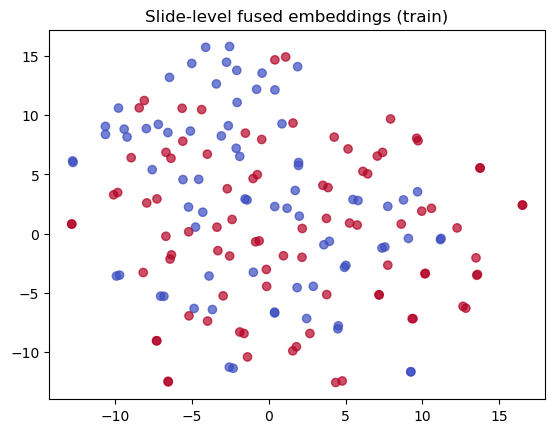

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
emb2d = tsne.fit_transform(X['train'])  # or np.vstack([...]) for all splits
plt.scatter(emb2d[:,0], emb2d[:,1], c=y['train'], cmap='coolwarm', alpha=0.7)
plt.title('Slide-level fused embeddings (train)')


In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# L2-normalize per slide
Xn_train = normalize(X['train'])
Xn_val   = normalize(X['val'])
Xn_test  = normalize(X['test'])

# Reduce dimensionality
pca = PCA(n_components=164, whiten=True, random_state=42)
Xp_train = pca.fit_transform(Xn_train)
Xp_val   = pca.transform(Xn_val)
Xp_test  = pca.transform(Xn_test)

# Regularized LR
clf = LogisticRegression(max_iter=10, C=0.1, penalty='l2', class_weight='balanced')
clf.fit(Xp_train, y['train'])

for split, Xp, ytrue in [('train',Xp_train,y['train']),
                         ('val',Xp_val,y['val']),
                         ('test',Xp_test,y['test'])]:
    yp = clf.predict(Xp)
    ypr = clf.predict_proba(Xp)[:,1]
    acc = accuracy_score(ytrue, yp)
    auc = roc_auc_score(ytrue, ypr)
    print(f"{split.upper()}: ACC={acc:.3f}  AUC={auc:.3f}")


TRAIN: ACC=1.000  AUC=1.000
VAL: ACC=0.837  AUC=0.898
TEST: ACC=0.485  AUC=0.535


In [ ]:
# ========= Multi-scale UNI (2.5× + 5×) with ATTENTION MIL (slide-level) =========
import os, glob, h5py, numpy as np, pandas as pd, torch, torch.nn as nn
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from sklearn.metrics import accuracy_score, roc_auc_score

# --- Directories ---
DIR_5X   = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\uniextracted_mag5x_patch224_fp\feats_h5"
DIR_2P5  = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_2.5x\uniextracted_mag2x_patch224_fp\feats_h5"

# --- Splits ---
CSV_TRAIN = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\FA_PT_k=0\train.csv"
CSV_VAL   = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\FA_PT_k=0\val.csv"
CSV_TEST  = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\FA_PT_k=0\test.csv"

# Mapping params (2.5× -> 5×)
PATCH = 224
RATIO = 2.0
TOL   = 8
OFF_X_5X = 0
OFF_Y_5X = 0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)

# ---------- data utils (same logic you used before) ----------
def list_h5(d: str) -> Dict[str,str]:
    out = {}
    for p in glob.glob(os.path.join(d, "*.h5")) + glob.glob(os.path.join(d, "*.hdf5")):
        out[Path(p).stem] = p
    return out

def load_h5(h: str):
    with h5py.File(h, "r") as f:
        return f["features"][:], f["coords"][:]

def coord_index(coords: np.ndarray) -> Dict[Tuple[int,int], int]:
    return {(int(x),int(y)): i for i,(x,y) in enumerate(coords)}

def find_idx(idx: Dict[Tuple[int,int],int], x: int, y: int, tol: int=0) -> Optional[int]:
    if (x,y) in idx: return idx[(x,y)]
    if tol<=0: return None
    for dx in range(-tol, tol+1):
        for dy in range(-tol, tol+1):
            k=(x+dx, y+dy)
            if k in idx: return idx[k]
    return None

def quad_5x_from_2p5(x2:int,y2:int):
    x5 = int(round(x2*RATIO))+OFF_X_5X
    y5 = int(round(y2*RATIO))+OFF_Y_5X
    return [(x5,y5),(x5+PATCH,y5),(x5,y5+PATCH),(x5+PATCH,y5+PATCH)]

def fuse_patch(feat2: np.ndarray, f5_list: List[np.ndarray]) -> np.ndarray:
    # L2-normalize per scale before fusion (helps generalization)
    f2 = feat2 / (np.linalg.norm(feat2)+1e-8)
    if len(f5_list)==0:
        f5m = np.zeros_like(f2)
    else:
        f5m = np.mean(np.stack(f5_list,0),0)
        f5m = f5m / (np.linalg.norm(f5m)+1e-8)
    return np.concatenate([f2, f5m], 0)   # 2048-D if UNI=1024

def lse_pool(feats, tau=1.0, eps=1e-6):
    # feats: [m, D], tau>0
    x = np.stack(feats, 0)                      # [m,D]
    mx = x.max(axis=0, keepdims=True)
    return (mx + tau*np.log(np.exp((x-mx)/tau).sum(axis=0, keepdims=True)+eps)).squeeze(0)

# attention fusion
# # f2: (D,), F5: (4, D) neighbors; all L2-normalized
# def fuse_patch(f2, F5):
#     if len(F5)==0: 
#         return np.concatenate([f2, np.zeros_like(f2)], 0)
#     # scores = similarity(2.5×, 5×i); use dot since L2-normed
#     s = F5 @ f2                                  # [4,]
#     w = np.exp(s - s.max()); w /= (w.sum()+1e-8) # softmax
#     f5_attn = (w[:,None] * F5).sum(0)
#     return np.concatenate([f2, f5_attn], 0)      # 2D


def load_split(csv_path: str) -> Dict[str,int]:
    df = pd.read_csv(csv_path)
    df['label_int'] = df['label'].map({'FA':0,'PT':1}).astype(int)
    return dict(zip(df['slide_id'], df['label_int']))

# Build per-slide fused bags (list of instance features)
h5_2p5 = list_h5(DIR_2P5); h5_5x = list_h5(DIR_5X)
common = sorted(set(h5_2p5).intersection(h5_5x))

def build_bag(slide_id: str) -> np.ndarray:
    f2, c2 = load_h5(h5_2p5[slide_id])
    f5, c5 = load_h5(h5_5x[slide_id])
    idx5 = coord_index(c5)
    fused = []
    for i in range(c2.shape[0]):
        x2,y2 = int(c2[i,0]), int(c2[i,1])
        neigh = []
        for (qx,qy) in quad_5x_from_2p5(x2,y2):
            j = find_idx(idx5, qx,qy, tol=TOL)
            if j is not None: neigh.append(f5[j])
        # fused.append(fuse_patch(f2[i], neigh)) # mean fusion
        fused.append(lse_pool([f2[i]] + neigh, tau=1.0))  # LSE pooling

    return np.stack(fused,0)  # [N_i, 2048]

splits = {'train': load_split(CSV_TRAIN),
          'val':   load_split(CSV_VAL),
          'test':  load_split(CSV_TEST)}

# Keep only slides available at both scales
for k in splits:
    splits[k] = {sid:lab for sid,lab in splits[k].items() if sid in common}

# ---------- dataset (bags) ----------
class SlideBags(torch.utils.data.Dataset):
    def __init__(self, split_map: Dict[str,int]):
        self.items = [(sid,lab) for sid,lab in split_map.items()]
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        sid, lab = self.items[i]
        bag = build_bag(sid)                 # [N_i, D]
        return sid, torch.from_numpy(bag).float(), torch.tensor(lab).long()

train_ds = SlideBags(splits['train'])
val_ds   = SlideBags(splits['val'])
test_ds  = SlideBags(splits['test'])

# ---------- Gated Attention MIL (Ilse et al. 2018) ----------
class GatedAttentionMIL(nn.Module):
    def __init__(self, in_dim: int, hid: int = 256, attn_dim: int = 128, n_classes: int = 2, dropout: float=0.25):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(dropout)
        )
        self.attn_V = nn.Linear(hid, attn_dim)
        self.attn_U = nn.Linear(hid, attn_dim)
        self.attn_w = nn.Linear(attn_dim, 1)
        self.classifier = nn.Linear(hid, n_classes)

    def forward(self, X: torch.Tensor):
        """
        X: [N_i, D]
        Returns: logits [1, C], attn_weights [N_i]
        """
        H = self.embed(X)                        # [N_i, H]
        A = torch.tanh(self.attn_V(H)) * torch.sigmoid(self.attn_U(H))  # [N_i, A]
        A = self.attn_w(A).squeeze(-1)          # [N_i]
        A = torch.softmax(A, dim=0)             # attention weights
        M = torch.sum(H * A.unsqueeze(-1), dim=0, keepdim=True)  # [1, H]
        logits = self.classifier(M)             # [1, C]
        return logits, A

# infer input dim from one training slide
with torch.no_grad():
    _, bag0, _ = train_ds[0]
in_dim = bag0.shape[1]
model = GatedAttentionMIL(in_dim=in_dim).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

def run_epoch(ds, train: bool):
    model.train(mode=train)
    tot_loss, preds, probs, gts = 0.0, [], [], []
    for i in range(len(ds)):
        sid, bag, y = ds[i]
        bag = bag.to(device)     # [N_i, D]
        y   = y.to(device).unsqueeze(0)  # [1]
        logits, _ = model(bag)
        loss = crit(logits, y)
        if train:
            opt.zero_grad(); loss.backward(); opt.step()
        tot_loss += loss.item()
        with torch.no_grad():
            p = torch.softmax(logits, dim=1)[0,1].item()
            probs.append(p); preds.append(int(p>=0.5)); gts.append(y.item())
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(gts, probs) if len(set(gts))>1 else float('nan')
    acc = accuracy_score(gts, preds)
    return tot_loss/len(ds), acc, auc

best_val, best_state = -1, None
for epoch in range(1, 51):
    tr_loss, tr_acc, tr_auc = run_epoch(train_ds, True)
    va_loss, va_acc, va_auc = run_epoch(val_ds, False)
    if va_auc > best_val:
        best_val, best_state = va_auc, {k:v.cpu().clone() for k,v in model.state_dict().items()}
    print(f"ep{epoch:02d} | train L{tr_loss:.3f} A{tr_acc:.3f} U{tr_auc:.3f} || val L{va_loss:.3f} A{va_acc:.3f} U{va_auc:.3f}")

# load best and test
model.load_state_dict(best_state)
te_loss, te_acc, te_auc = run_epoch(test_ds, False)
print(f"TEST | ACC={te_acc:.3f}  AUC={te_auc:.3f}")

# ---- (optional) inspect attention on one slide ----
with torch.no_grad():
    sid, bag, y = val_ds[0]
    logits, A = model(bag.to(device))
    print("Top-5 attended instances (idx, weight):")
    top = torch.topk(A, k=min(5, len(A)))[1].cpu().numpy().tolist()
    for i in top:
        print(i, float(A[i].cpu()))


In [11]:
# ====== K-fold CV with single-scale baselines + LATE FUSION (stacker) ======
import os, glob, h5py, numpy as np, pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# -------------------- EDIT THESE --------------------
DIR_5X   = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\uniextracted_mag5x_patch224_fp\feats_h5"
DIR_2P5  = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_2.5x\uniextracted_mag2x_patch224_fp\feats_h5"
SPLITS_ROOT = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\cross-val"  # FA_PT_k=0..4

USE_PCA = False
PCA_NC  = 256
LR_C    = 0.1
LR_CLASS_WEIGHT = 'balanced'
# ----------------------------------------------------

def list_h5(dir_path): 
    return {Path(p).stem: p for p in glob.glob(os.path.join(dir_path, "*.h5"))+glob.glob(os.path.join(dir_path, "*.hdf5"))}

def load_h5_feats(h5_path):
    with h5py.File(h5_path, "r") as f:
        feats = f["features"][:]
    # L2 normalize per patch to stabilize slide means
    feats = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)
    return feats

def slide_vec_mean(h5_map, sid):
    F = load_h5_feats(h5_map[sid])
    return F.mean(axis=0)  # [D]

def load_split(csv_path):
    df = pd.read_csv(csv_path)
    df['label_int'] = df['label'].map({'FA':0, 'PT':1}).astype(int)
    return dict(zip(df['slide_id'], df['label_int']))

def eval_set(X, y, clf):
    yp  = clf.predict(X)
    ypr = clf.predict_proba(X)[:,1]
    return accuracy_score(y, yp), roc_auc_score(y, ypr), ypr

# inventories
h5_2p5 = list_h5(DIR_2P5)
h5_5x  = list_h5(DIR_5X)

fold_dirs = sorted([d for d in glob.glob(os.path.join(SPLITS_ROOT, "FA_PT_k=*")) if os.path.isdir(d)],
                   key=lambda p: int(Path(p).name.split('=')[-1]))
print("Found folds:", [Path(d).name for d in fold_dirs])

records = []
for fold_idx, fdir in enumerate(fold_dirs):
    maps = {s: load_split(os.path.join(fdir, f"{s}.csv")) for s in ["train","val","test"]}

    # Build per-scale slide vectors (keep only slides that exist for that scale)
    X2, X5, y = {}, {}, {}
    for split, mp in maps.items():
        X2s, X5s, ys = [], [], []
        for sid, lab in mp.items():
            if sid in h5_2p5:
                X2s.append(slide_vec_mean(h5_2p5, sid))
                has2 = True
            else:
                has2 = False
            if sid in h5_5x:
                X5s.append(slide_vec_mean(h5_5x, sid))
                has5 = True
            else:
                has5 = False
            if has2 and has5:
                ys.append(lab)
            elif has2:  # still append to maintain aligned pairs per scale below
                ys.append(lab)
            elif has5:
                ys.append(lab)
        # Convert
        X2[split] = np.vstack(X2s) if len(X2s)>0 else None
        X5[split] = np.vstack(X5s) if len(X5s)>0 else None
        y[split]  = np.array(ys, dtype=int)

    # --- Standardize (per-scale, fit on train) + optional PCA (per-scale) ---
    def scale_and_pca(train, val, test):
        scaler = StandardScaler()
        Xt = scaler.fit_transform(train)
        Xv = scaler.transform(val)
        Xs = scaler.transform(test)
        if USE_PCA:
            n_comp = min(PCA_NC, Xt.shape[1], max(2, Xt.shape[0]-5))
            pca = PCA(n_components=n_comp, whiten=True, random_state=42, svd_solver='full')
            Xt = pca.fit_transform(Xt); Xv = pca.transform(Xv); Xs = pca.transform(Xs)
        return Xt, Xv, Xs

    X2_train, X2_val, X2_test = scale_and_pca(X2['train'], X2['val'], X2['test'])
    X5_train, X5_val, X5_test = scale_and_pca(X5['train'], X5['val'], X5['test'])

    # --- Train single-scale models ---
    clf2 = LogisticRegression(max_iter=2000, C=LR_C, penalty='l2', class_weight=LR_CLASS_WEIGHT).fit(X2_train, y['train'])
    clf5 = LogisticRegression(max_iter=2000, C=LR_C, penalty='l2', class_weight=LR_CLASS_WEIGHT).fit(X5_train, y['train'])

    tr2_acc, tr2_auc, _ = eval_set(X2_train, y['train'], clf2)
    va2_acc, va2_auc, pr2_val = eval_set(X2_val,   y['val'],   clf2)
    te2_acc, te2_auc, pr2_te  = eval_set(X2_test,  y['test'],  clf2)

    tr5_acc, tr5_auc, _ = eval_set(X5_train, y['train'], clf5)
    va5_acc, va5_auc, pr5_val = eval_set(X5_val,   y['val'],   clf5)
    te5_acc, te5_auc, pr5_te  = eval_set(X5_test,  y['test'],  clf5)

    # --- LATE FUSION: train a stacker on validation logits/probs ---
    # Use decision_function if available; here we use probabilities
    Z_val  = np.c_[pr2_val, pr5_val]  # [N_val, 2]
    Z_test = np.c_[pr2_te,  pr5_te]   # [N_test,2]

    stack = LogisticRegression(max_iter=2000).fit(Z_val, y['val'])
    ypr_te = stack.predict_proba(Z_test)[:,1]
    yhat_te = (ypr_te >= 0.5).astype(int)
    te_acc_fuse = accuracy_score(y['test'], yhat_te)
    te_auc_fuse = roc_auc_score(y['test'], ypr_te)

    records.append({
        "fold": fold_idx,
        "train_acc_2p5": tr2_acc, "train_auc_2p5": tr2_auc,
        "val_acc_2p5": va2_acc,   "val_auc_2p5": va2_auc,
        "test_acc_2p5": te2_acc,  "test_auc_2p5": te2_auc,
        "train_acc_5x": tr5_acc,  "train_auc_5x": tr5_auc,
        "val_acc_5x": va5_acc,    "val_auc_5x": va5_auc,
        "test_acc_5x": te5_acc,   "test_auc_5x": te5_auc,
        "test_acc_fuse": te_acc_fuse, "test_auc_fuse": te_auc_fuse,
        "n_train": len(y['train']), "n_val": len(y['val']), "n_test": len(y['test'])
    })

cv_df = pd.DataFrame(records)
print(cv_df[["fold",
             "test_acc_2p5","test_auc_2p5",
             "test_acc_5x","test_auc_5x",
             "test_acc_fuse","test_auc_fuse"]])

def mean_std(s): return f"{cv_df[s].mean():.3f} ± {cv_df[s].std():.3f}"
print("\nSummary across folds")
print("2.5x  TEST  ACC:", mean_std("test_acc_2p5"), "  AUC:", mean_std("test_auc_2p5"))
print("5x    TEST  ACC:", mean_std("test_acc_5x"),  "  AUC:", mean_std("test_auc_5x"))
print("FUSION TEST  ACC:", mean_std("test_acc_fuse"),"  AUC:", mean_std("test_auc_fuse"))


Found folds: ['FA_PT_k=0', 'FA_PT_k=1', 'FA_PT_k=2', 'FA_PT_k=3', 'FA_PT_k=4']
   fold  test_acc_2p5  test_auc_2p5  test_acc_5x  test_auc_5x  test_acc_fuse  \
0     0      0.617021      0.670909     0.510638     0.621818       0.574468   
1     1      0.708333      0.834783     0.770833     0.827826       0.791667   
2     2      0.666667      0.698000     0.644444     0.688000       0.644444   
3     3      0.775510      0.818333     0.734694     0.790000       0.775510   
4     4      0.784314      0.830769     0.823529     0.829231       0.784314   

   test_auc_fuse  
0       0.645455  
1       0.829565  
2       0.702000  
3       0.801667  
4       0.838462  

Summary across folds
2.5x  TEST  ACC: 0.710 ± 0.071   AUC: 0.771 ± 0.079
5x    TEST  ACC: 0.697 ± 0.123   AUC: 0.751 ± 0.092
FUSION TEST  ACC: 0.714 ± 0.099   AUC: 0.763 ± 0.085


In [25]:
# ==== MIL & DSMIL on pre-extracted features (UNI) ====
import os, glob, h5py, numpy as np, pandas as pd, torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score

# -------------------- EDIT THESE --------------------
DIR_5X   = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\uniextracted_mag5x_patch224_fp\feats_h5"
DIR_2P5  = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_2.5x\uniextracted_mag2x_patch224_fp\feats_h5"
SPLITS_ROOT = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\cross-val"  # FA_PT_k=0..4
MODE = "mixed"   # "2.5x", "5x", or "mixed"
BATCH_SIZE = 1   # one bag per batch
EPOCHS = 30
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# ----------------------------------------------------

def list_h5(dir_path):
    return {Path(p).stem: p for p in glob.glob(os.path.join(dir_path, "*.h5"))}

def load_feats(h5_path):
    with h5py.File(h5_path, "r") as f:
        F = f["features"][:].astype(np.float32)
    # L2 normalize per instance (helps MIL)
    F /= (np.linalg.norm(F, axis=1, keepdims=True) + 1e-8)
    return F

h5_2p5 = list_h5(DIR_2P5)
h5_5x  = list_h5(DIR_5X)

def load_split(csv_path):
    df = pd.read_csv(csv_path)
    y = df["label"].map({"FA":0, "PT":1}).astype(int).to_dict()
    return y

# from previous code snippet
import os, glob, h5py, numpy as np, pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# -------------------- EDIT THESE --------------------
DIR_5X   = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\uniextracted_mag5x_patch224_fp\feats_h5"
DIR_2P5  = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_2.5x\uniextracted_mag2x_patch224_fp\feats_h5"
SPLITS_ROOT = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\cross-val"  # FA_PT_k=0..4

USE_PCA = False
PCA_NC  = 256
LR_C    = 0.1
LR_CLASS_WEIGHT = 'balanced'
# ----------------------------------------------------

def list_h5(dir_path): 
    return {Path(p).stem: p for p in glob.glob(os.path.join(dir_path, "*.h5"))+glob.glob(os.path.join(dir_path, "*.hdf5"))}

def load_h5_feats(h5_path):
    with h5py.File(h5_path, "r") as f:
        feats = f["features"][:]
    # L2 normalize per patch to stabilize slide means
    feats = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)
    return feats

def slide_vec_mean(h5_map, sid):
    F = load_h5_feats(h5_map[sid])
    return F.mean(axis=0)  # [D]

def load_split(csv_path):
    df = pd.read_csv(csv_path)
    df['label_int'] = df['label'].map({'FA':0, 'PT':1}).astype(int)
    return dict(zip(df['slide_id'], df['label_int']))

def eval_set(X, y, clf):
    yp  = clf.predict(X)
    ypr = clf.predict_proba(X)[:,1]
    return accuracy_score(y, yp), roc_auc_score(y, ypr), ypr

# inventories
h5_2p5 = list_h5(DIR_2P5)
h5_5x  = list_h5(DIR_5X)

fold_dirs = sorted([d for d in glob.glob(os.path.join(SPLITS_ROOT, "FA_PT_k=*")) if os.path.isdir(d)],
                   key=lambda p: int(Path(p).name.split('=')[-1]))
print("Found folds:", [Path(d).name for d in fold_dirs])

# records = []
# for fold_idx, fdir in enumerate(fold_dirs):
#     maps = {s: load_split(os.path.join(fdir, f"{s}.csv")) for s in ["train","val","test"]}

#     # Build per-scale slide vectors (keep only slides that exist for that scale)
#     X2, X5, y = {}, {}, {}
#     for split, mp in maps.items():
#         X2s, X5s, ys = [], [], []
#         for sid, lab in mp.items():
#             if sid in h5_2p5:
#                 X2s.append(slide_vec_mean(h5_2p5, sid))
#                 has2 = True
#             else:
#                 has2 = False
#             if sid in h5_5x:
#                 X5s.append(slide_vec_mean(h5_5x, sid))
#                 has5 = True
#             else:
#                 has5 = False
#             if has2 and has5:
#                 ys.append(lab)
#             elif has2:  # still append to maintain aligned pairs per scale below
#                 ys.append(lab)
#             elif has5:
#                 ys.append(lab)
#         # Convert
#         X2[split] = np.vstack(X2s) if len(X2s)>0 else None
#         X5[split] = np.vstack(X5s) if len(X5s)>0 else None
#         y[split]  = np.array(ys, dtype=int)

# --------- Bag builders ---------
def build_bag_single(sid, which):
    if which == "2.5x":
        F = load_feats(h5_2p5[sid])
    elif which == "5x":
        F = load_feats(h5_5x[sid])
    else:
        raise ValueError
    return F  # [N, D]

def build_bag_mixed(sid):
    F2 = load_feats(h5_2p5[sid]) if sid in h5_2p5 else np.empty((0,1024), np.float32)
    F5 = load_feats(h5_5x[sid])  if sid in h5_5x  else np.empty((0,1024), np.float32)
    # attach a scale id per instance: 0 for 2.5x, 1 for 5x
    S2 = np.zeros((len(F2), 1), np.float32)
    S5 = np.ones ((len(F5), 1), np.float32)
    X  = np.concatenate([F2, F5], axis=0)              # [N, 1024]
    S  = np.concatenate([S2, S5], axis=0)              # [N, 1]
    return X, S

# --------- Datasets ---------
class SlideBags(torch.utils.data.Dataset):
    def __init__(self, split_map: Dict[str,int], mode: str):
        self.mode = mode
        if mode == "2.5x":
            self.items = [(sid, lab) for sid, lab in split_map.items() if sid in h5_2p5]
        elif mode == "5x":
            self.items = [(sid, lab) for sid, lab in split_map.items() if sid in h5_5x]
        elif mode == "mixed":
            self.items = [(sid, lab) for sid, lab in split_map.items()
                          if (sid in h5_2p5) or (sid in h5_5x)]
        else:
            raise ValueError("mode must be '2.5x', '5x', or 'mixed'")

    def __len__(self): return len(self.items)

    def __getitem__(self, i):
        sid, lab = self.items[i]
        if self.mode in ("2.5x","5x"):
            X = build_bag_single(sid, self.mode)          # [N,D]
            return sid, torch.from_numpy(X), torch.tensor(lab)
        else:  # mixed
            X, S = build_bag_mixed(sid)                   # [N,D], [N,1]
            return sid, torch.from_numpy(X), torch.from_numpy(S), torch.tensor(lab)


# --------- MIL heads ---------
class GatedAttentionMIL(nn.Module):
    # Ilse et al. (2018)
    def __init__(self, in_dim, hid=256, attn_dim=128, n_classes=2, dropout=0.25):
        super().__init__()
        self.embed = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(dropout))
        self.U = nn.Linear(hid, attn_dim)
        self.V = nn.Linear(hid, attn_dim)
        self.w = nn.Linear(attn_dim, 1)
        self.cls = nn.Linear(hid, n_classes)
    def forward(self, X):                   # X: [N,D]
        H = self.embed(X)                   # [N,H]
        A = torch.tanh(self.V(H)) * torch.sigmoid(self.U(H))
        A = torch.softmax(self.w(A).squeeze(-1), dim=0)          # [N]
        M = torch.sum(H * A.unsqueeze(-1), dim=0, keepdim=True)  # [1,H]
        logits = self.cls(M)                                      # [1,C]
        return logits, A

class DSMILHead(nn.Module):
    # Li et al., CVPR 2021 — simple dual-stream variant
    def __init__(self, in_dim, hid=256, n_classes=2, dropout=0.25):
        super().__init__()
        self.f_inst = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(dropout))
        self.f_bag  = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(dropout))
        self.W = nn.Linear(hid, hid, bias=False)
        self.cls = nn.Linear(hid, n_classes)
    def forward(self, X):                   # X: [N,D]
        Zi = self.f_inst(X)                 # [N,H]
        zb = self.f_bag(X).mean(0)          # [H]
        a  = torch.softmax(Zi @ self.W(zb), dim=0)   # [N]
        M  = (a.unsqueeze(1) * Zi).sum(0, keepdim=True)  # [1,H]
        logits = self.cls(M)                # [1,C]
        return logits, a

# Optional: scale embedding for mixed-bag
class ScaleMLP(nn.Module):
    # adds a small learned embedding for scale and fuses with features
    def __init__(self, feat_dim=1024, scale_dim=8, out_dim=1024):
        super().__init__()
        self.emb = nn.Embedding(2, scale_dim)  # 0=2.5x, 1=5x
        self.proj = nn.Linear(feat_dim + scale_dim, out_dim)
        self.act = nn.ReLU()
    def forward(self, X, S):
        # X:[N,D], S:[N,1] with 0/1
        e = self.emb(S.long().squeeze(-1))     # [N,scale_dim]
        Z = torch.cat([X, e], dim=1)
        return self.act(self.proj(Z))          # [N,out_dim]

# --------- Training/eval loops ---------
def train_epoch(loader, model, criterion, optim, mixed=False, scaler_mlp=None):
    model.train()
    tot = 0.0
    for batch in loader:
        if mixed:
            _, X, S, y = batch
            # squeeze optional batch dim
            if X.dim()==3: X, S = X.squeeze(0), S.squeeze(0)
            X, S = X.to(DEVICE), S.to(DEVICE)
            if scaler_mlp is not None:
                X = scaler_mlp(X, S)
        else:
            _, X, y = batch
            if X.dim()==3: X = X.squeeze(0)
            X = X.to(DEVICE)

        # ---- make target 1D LongTensor of size [1] ----
        if isinstance(y, torch.Tensor):
            y = y.detach()
            if y.dim()==0:
                y = y.view(1)         # () -> (1,)
            else:
                y = y.view(-1)        # (1,) stays (1,)
            y = y.long().to(DEVICE)
        else:
            y = torch.tensor([int(y)], dtype=torch.long, device=DEVICE)

        logits, _ = model(X)           # [1, C]
        loss = criterion(logits, y)    # y: [1]
        optim.zero_grad(); loss.backward(); optim.step()
        tot += loss.item()
    return tot / max(1, len(loader))

@torch.no_grad()
def eval_epoch(loader, model, mixed=False, scaler_mlp=None):
    model.eval()
    y_true, y_prob = [], []
    for batch in loader:
        if mixed:
            _, X, S, y = batch
            if X.dim()==3: X, S = X.squeeze(0), S.squeeze(0)
            X, S = X.to(DEVICE), S.to(DEVICE)
            if scaler_mlp is not None:
                X = scaler_mlp(X, S)
        else:
            _, X, y = batch
            if X.dim()==3: X = X.squeeze(0)
            X = X.to(DEVICE)

        logits, _ = model(X)
        p = torch.softmax(logits, dim=-1)[0, 1].item()

        # robust scalar extract
        y_true.append(int(y.item() if isinstance(y, torch.Tensor) else y))
        y_prob.append(p)

    y_true = np.array(y_true); y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true))>1 else float("nan")
    return acc, auc

# --- helper: make safe loaders for any mode ---
def make_loader(ds, shuffle=True):
    n = len(ds)
    if n == 0:
        raise RuntimeError(f"No slides for mode='{getattr(ds,'mode','?')}' in this split.")
    return DataLoader(ds, batch_size=1, shuffle=(shuffle and n > 1), num_workers=0)

# --------- Run per fold ---------
for fold_idx, fdir in enumerate(fold_dirs):
    maps = {s: load_split(os.path.join(fdir, f"{s}.csv")) for s in ["train","val","test"]}
    if MODE in ("2.5x","5x"):
        Train = SlideBags(maps["train"], MODE)
        Val   = SlideBags(maps["val"],   MODE)
        Test  = SlideBags(maps["test"],  MODE)


        # skip empty folds cleanly
        if len(Train)==0 or len(Val)==0 or len(Test)==0:
            print(f"[fold {fold_idx}] skip: empty split "
                  f"(train={len(Train)}, val={len(Val)}, test={len(Test)})")
            continue

        trL = make_loader(Train, shuffle=True)
        vaL = make_loader(Val,   shuffle=False)
        teL = make_loader(Test,  shuffle=False)

        # ... training/eval exactly as you had ...

    # ---- MIXED branch (replace your lambda loader + adds guards/prints) ----
    elif MODE == "mixed":
        Train = SlideBags(maps["train"], "mixed")
        Val   = SlideBags(maps["val"],   "mixed")
        Test  = SlideBags(maps["test"],  "mixed")

        print(f"[fold {fold_idx}] counts — train:{len(Train)} val:{len(Val)} test:{len(Test)} mode:mixed")
        if len(Train)==0 or len(Val)==0 or len(Test)==0:
            print(f"[fold {fold_idx}] skip: empty split"); 
            continue

        trL = make_loader(Train, shuffle=True)
        vaL = make_loader(Val,   shuffle=False)
        teL = make_loader(Test,  shuffle=False)

        scale_mlp = ScaleMLP(feat_dim=1024, scale_dim=8, out_dim=1024).to(DEVICE)
        # mil = DSMILHead(in_dim=1024).to(DEVICE)   
        mil = GatedAttentionMIL(in_dim=1024).to(DEVICE) # or GatedAttentionMIL(1024)
        crit = nn.CrossEntropyLoss()
        opt  = torch.optim.Adam(list(mil.parameters())+list(scale_mlp.parameters()),
                                lr=LR, weight_decay=1e-4)

        for ep in range(EPOCHS):
            _ = train_epoch(trL, mil, crit, opt, mixed=True, scaler_mlp=scale_mlp)

        tr_acc, tr_auc = eval_epoch(trL, mil, mixed=True, scaler_mlp=scale_mlp)
        va_acc, va_auc = eval_epoch(vaL, mil, mixed=True, scaler_mlp=scale_mlp)
        te_acc, te_auc = eval_epoch(teL, mil, mixed=True, scaler_mlp=scale_mlp)
        print(f"[fold {fold_idx} | mixed DSMIL] TRAIN {tr_acc:.3f}/{tr_auc:.3f} "
            f"VAL {va_acc:.3f}/{va_auc:.3f} TEST {te_acc:.3f}/{te_auc:.3f}")

Found folds: ['FA_PT_k=0', 'FA_PT_k=1', 'FA_PT_k=2', 'FA_PT_k=3', 'FA_PT_k=4']
[fold 0] counts — train:155 val:38 test:47 mode:mixed
[fold 0 | mixed DSMIL] TRAIN 1.000/1.000 VAL 0.579/0.683 TEST 0.553/0.651
[fold 1] counts — train:157 val:35 test:48 mode:mixed
[fold 1 | mixed DSMIL] TRAIN 1.000/1.000 VAL 0.629/0.725 TEST 0.688/0.767
[fold 2] counts — train:157 val:38 test:45 mode:mixed
[fold 2 | mixed DSMIL] TRAIN 0.975/0.998 VAL 0.658/0.811 TEST 0.644/0.596
[fold 3] counts — train:156 val:35 test:49 mode:mixed
[fold 3 | mixed DSMIL] TRAIN 0.897/0.997 VAL 0.743/0.866 TEST 0.755/0.793
[fold 4] counts — train:149 val:40 test:51 mode:mixed
[fold 4 | mixed DSMIL] TRAIN 0.993/0.997 VAL 0.625/0.750 TEST 0.765/0.848


In [26]:
# 2.5x and 10x
import numpy as np, h5py
from scipy.spatial import cKDTree

# --- scale/meta (adjust if different in your data) ---
PATCH_2P5 = 224
PATCH_10  = 224
RATIO_10_FROM_2P5 = 10.0/2.5  # = 4.0  (coords scale from 2.5× to 10×)
OFF_X_10, OFF_Y_10 = 0, 0     # set if you know fixed offsets

def load_feats_coords(h5p):
    with h5py.File(h5p, "r") as f:
        F = f["features"][:].astype(np.float32)
        C = f["coords"][:].astype(np.float32)
    # L2-norm per instance for stability
    F /= (np.linalg.norm(F, axis=1, keepdims=True) + 1e-8)
    return F, C

def map_center_to_10x(c2):
    # c2: [2] at 2.5× → center in 10× space
    return np.array([c2[0]*RATIO_10_FROM_2P5 + OFF_X_10,
                     c2[1]*RATIO_10_FROM_2P5 + OFF_Y_10], dtype=np.float32)

def fuse_concat(f2, f10):             # simplest fusion
    return np.concatenate([f2, f10], 0)

def fuse_attn_by_dist(f2, kids10, dists, sigma=None):
    # soft weight by distance; use 1 neighbor if kids10.shape[0]==1
    if len(kids10)==0: return np.concatenate([f2, np.zeros_like(f2)], 0)
    if sigma is None: sigma = PATCH_10 * 0.6
    w = np.exp(- (dists**2) / (2*sigma**2)); w = w / (w.sum()+1e-8)
    f10 = (w[:,None] * kids10).sum(0)
    return np.concatenate([f2, f10], 0)

def build_concentric_instances(h5_2p5_path, h5_10x_path, k_neighbors=1, radius_px=None, fuse="concat"):
    """
    Returns: X [N_parents, 2D] built by pairing each 2.5× centroid to nearest 10× patch(es).
    If radius_px is given, use all 10× within radius; else use top-k neighbors.
    """
    F2, C2 = load_feats_coords(h5_2p5_path)
    F10, C10 = load_feats_coords(h5_10x_path)
    tree = cKDTree(C10)

    X = []
    for i in range(C2.shape[0]):
        c10 = map_center_to_10x(C2[i])
        if radius_px is not None:
            idxs = tree.query_ball_point(c10, r=radius_px)
            kids = F10[idxs] if len(idxs)>0 else np.empty((0, F10.shape[1]), np.float32)
            dists = np.linalg.norm(C10[idxs]-c10, axis=1) if len(idxs)>0 else np.array([])
        else:
            dists, idxs = tree.query(c10, k=min(k_neighbors, len(F10)))
            if np.isscalar(idxs): idxs = [idxs]; dists = np.array([dists], dtype=np.float32)
            kids = F10[idxs]
        if kids.shape[0] == 0:
            xf = np.concatenate([F2[i], np.zeros_like(F2[i])], 0)
        else:
            if fuse == "concat" and kids.shape[0] == 1:
                xf = fuse_concat(F2[i], kids[0])
            else:
                xf = fuse_attn_by_dist(F2[i], kids, dists)
        X.append(xf)
    return np.stack(X, 0)  # [N_parents, 2048] if each scale is 1024-D


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# Build per-slide bag then slide vector
X_train, y_train = [], []
for sid, lab in split_train.items():
    Xbag = build_concentric_instances(h5_2p5[sid], h5_10x[sid], k_neighbors=1)  # [N,2048]
    X_train.append(Xbag.mean(0)); y_train.append(lab)
X_train, y_train = np.vstack(X_train), np.array(y_train)

# scale → LR
sc = StandardScaler().fit(X_train)
Xt = sc.transform(X_train)
clf = LogisticRegression(max_iter=2000, class_weight='balanced').fit(Xt, y_train)

# evaluate
def eval_split(split_map):
    Xs, ys = [], []
    for sid, lab in split_map.items():
        Xbag = build_concentric_instances(h5_2p5[sid], h5_10x[sid], k_neighbors=1)
        Xs.append(Xbag.mean(0)); ys.append(lab)
    Xs, ys = sc.transform(np.vstack(Xs)), np.array(ys)
    pr = clf.predict_proba(Xs)[:,1]
    return accuracy_score(ys, (pr>=0.5).astype(int)), roc_auc_score(ys, pr)

acc_val, auc_val = eval_split(split_val)
acc_te,  auc_te  = eval_split(split_test)
print("VAL", acc_val, auc_val, "TEST", acc_te, auc_te)


In [29]:
# ============================================================
# Concentric 2.5× ↔ 10× pairing + simple fusion baselines
# - Builds per-slide fused patch features by pairing each 2.5×
#   patch (by centroid) to the nearest 10× patch (or neighbors).
# - Runs two quick baselines:
#     (A) Slide-mean + Logistic Regression
#     (B) (optional) Gated Attention MIL on fused instances
# ============================================================
import os, glob
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
from scipy.spatial import cKDTree

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# (Optional MIL)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------- EDIT THESE --------------------
DIR_2P5 = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_2.5x\uniextracted_mag2x_patch224_fp\feats_h5"
DIR_10X = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_10x\uniextracted_mag10x_patch224_fp\feats_h5"
SPLITS_ROOT = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\cross-val\FA_PT_k=0"   # single fold for now

CSV_TRAIN = os.path.join(SPLITS_ROOT, "train.csv")
CSV_VAL   = os.path.join(SPLITS_ROOT, "val.csv")
CSV_TEST  = os.path.join(SPLITS_ROOT, "test.csv")

# Concentric mapping params
PATCH_2P5 = 224
PATCH_10  = 224
RATIO_10_FROM_2P5 = 10.0 / 2.5     # = 4.0 (coords scale from 2.5× to 10×)
OFF_X_10, OFF_Y_10 = 0, 0          # set fixed offsets if needed

# Pairing behavior
K_NEIGHBORS = 1        # use 1-NN by default
RADIUS_PX   = None     # OR set e.g. int(PATCH_10*0.8) to use all neighbors in radius
FUSE_MODE   = "concat" # "concat" or "attn" (distance-weighted)

# Baseline toggles
RUN_LR  = False
RUN_MIL = True   # set True to also run MIL on fused instances
EPOCHS  = 20
LR_MIL  = 1e-3
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
# ----------------------------------------------------

# -------------------- IO helpers --------------------
def list_h5(dir_path: str):
    out = {}
    for p in glob.glob(os.path.join(dir_path, "*.h5")) + glob.glob(os.path.join(dir_path, "*.hdf5")):
        out[Path(p).stem] = p
    return out

def load_split(csv_path: str):
    df = pd.read_csv(csv_path)
    df["label_int"] = df["label"].map({"FA":0, "PT":1}).astype(int)
    return dict(zip(df["slide_id"].astype(str), df["label_int"]))

h5_2p5 = list_h5(DIR_2P5)
h5_10x = list_h5(DIR_10X)
print(f"Inventory — 2.5×:{len(h5_2p5)}  10×:{len(h5_10x)}")

split_train = load_split(CSV_TRAIN)
split_val   = load_split(CSV_VAL)
split_test  = load_split(CSV_TEST)
print(f"Splits — train:{len(split_train)} val:{len(split_val)} test:{len(split_test)}")

# -------------------- Concentric pairing --------------------
def load_feats_coords(h5p):
    with h5py.File(h5p, "r") as f:
        F = f["features"][:].astype(np.float32)
        C = f["coords"][:].astype(np.float32)
    # L2-normalize per instance
    F /= (np.linalg.norm(F, axis=1, keepdims=True) + 1e-8)
    return F, C

def map_center_to_10x(c2):
    # c2: [x,y] at 2.5× → center in 10× space
    return np.array([c2[0]*RATIO_10_FROM_2P5 + OFF_X_10,
                     c2[1]*RATIO_10_FROM_2P5 + OFF_Y_10], dtype=np.float32)

def fuse_concat(f2, f10):
    return np.concatenate([f2, f10], 0)

def fuse_attn_by_dist(f2, kids10, dists, sigma=None):
    # soft distance weighting over neighbors
    if kids10.shape[0] == 0:
        return np.concatenate([f2, np.zeros_like(f2)], 0)
    if sigma is None:
        sigma = PATCH_10 * 0.6
    w = np.exp(- (dists**2) / (2*sigma**2)); w = w / (w.sum()+1e-8)
    f10 = (w[:,None] * kids10).sum(0)
    return np.concatenate([f2, f10], 0)

def build_concentric_instances(h5_2p5_path, h5_10x_path,
                               k_neighbors=1, radius_px=None, fuse="concat"):
    """
    Returns: X [N_parents, 2D] by pairing each 2.5× centroid to nearest 10× patch(es).
    If radius_px is set, uses all 10× within radius with distance-weighted fusion.
    """
    F2, C2 = load_feats_coords(h5_2p5_path)
    F10, C10 = load_feats_coords(h5_10x_path)

    tree = cKDTree(C10)
    X = []
    for i in range(C2.shape[0]):
        c10 = map_center_to_10x(C2[i])
        if radius_px is not None:
            idxs = tree.query_ball_point(c10, r=radius_px)
            kids = F10[idxs] if len(idxs)>0 else np.empty((0, F10.shape[1]), np.float32)
            dists = np.linalg.norm(C10[idxs]-c10, axis=1) if len(idxs)>0 else np.array([])
        else:
            if len(F10) == 0:
                kids = np.empty((0, F2.shape[1]), np.float32); dists = np.array([])
            else:
                k = min(k_neighbors, len(F10))
                dists, idxs = tree.query(c10, k=k)
                if np.isscalar(idxs): idxs = [idxs]; dists = np.array([dists], dtype=np.float32)
                kids = F10[idxs]

        if kids.shape[0] == 0:
            x_fused = np.concatenate([F2[i], np.zeros_like(F2[i])], 0)
        else:
            if fuse == "concat" and kids.shape[0] == 1:
                x_fused = fuse_concat(F2[i], kids[0])
            else:
                x_fused = fuse_attn_by_dist(F2[i], kids, dists)
        X.append(x_fused)

    return np.stack(X, 0)  # [N_parents, 2048] if each scale is 1024-D

# -------------------- Baseline A: Slide-mean + LR --------------------
def build_slide_vector(slide_id):
    if (slide_id not in h5_2p5) or (slide_id not in h5_10x):
        return None
    Xbag = build_concentric_instances(h5_2p5[slide_id], h5_10x[slide_id],
                                      k_neighbors=K_NEIGHBORS,
                                      radius_px=RADIUS_PX,
                                      fuse=FUSE_MODE)
    return Xbag.mean(0)  # [2D]

def build_split_vectors(split_map):
    Xs, ys, kept = [], [], []
    for sid, lab in split_map.items():
        if sid in h5_2p5 and sid in h5_10x:
            vec = build_slide_vector(sid)
            if vec is not None:
                Xs.append(vec); ys.append(lab); kept.append(sid)
    return (np.vstack(Xs), np.array(ys, dtype=int), kept) if Xs else (None, None, [])

def run_lr_baseline():
    Xtr, ytr, keep_tr = build_split_vectors(split_train)
    Xva, yva, keep_va = build_split_vectors(split_val)
    Xte, yte, keep_te = build_split_vectors(split_test)
    print(f"[LR] kept slides — train:{len(keep_tr)} val:{len(keep_va)} test:{len(keep_te)}")

    scaler = StandardScaler().fit(Xtr)
    Xtr_s = scaler.transform(Xtr); Xva_s = scaler.transform(Xva); Xte_s = scaler.transform(Xte)

    clf = LogisticRegression(max_iter=2000, class_weight='balanced').fit(Xtr_s, ytr)

    def eval_set(X, y):
        pr = clf.predict_proba(X)[:,1]
        return accuracy_score(y, (pr>=0.5).astype(int)), roc_auc_score(y, pr)

    tr_acc, tr_auc = eval_set(Xtr_s, ytr)
    va_acc, va_auc = eval_set(Xva_s, yva)
    te_acc, te_auc = eval_set(Xte_s, yte)

    print(f"[LR] TRAIN  acc={tr_acc:.3f} auc={tr_auc:.3f}")
    print(f"[LR] VAL    acc={va_acc:.3f} auc={va_auc:.3f}")
    print(f"[LR] TEST   acc={te_acc:.3f} auc={te_auc:.3f}")

# -------------------- Baseline B: (optional) MIL on fused instances --------------------
class FusedBagDataset(Dataset):
    def __init__(self, split_map):
        self.items = [(sid, lab) for sid, lab in split_map.items() if (sid in h5_2p5) and (sid in h5_10x)]
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        sid, lab = self.items[idx]
        X = build_concentric_instances(h5_2p5[sid], h5_10x[sid],
                                       k_neighbors=K_NEIGHBORS,
                                       radius_px=RADIUS_PX,
                                       fuse=FUSE_MODE)  # [N, 2048]
        return torch.from_numpy(X).float(), torch.tensor(lab).long()

class GatedAttentionMIL(nn.Module):
    def __init__(self, in_dim=2048, hid=256, attn_dim=128, n_classes=2, p=0.25):
        super().__init__()
        self.embed = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(p))
        self.U, self.V = nn.Linear(hid, attn_dim), nn.Linear(hid, attn_dim)
        self.w = nn.Linear(attn_dim, 1)
        self.cls = nn.Linear(hid, n_classes)
    def forward(self, X):           # X: [N,D]
        H = self.embed(X)           # [N,H]
        A = torch.tanh(self.V(H)) * torch.sigmoid(self.U(H))
        A = torch.softmax(self.w(A).squeeze(-1), dim=0)          # [N]
        M = (H * A.unsqueeze(-1)).sum(0, keepdim=True)           # [1,H]
        return self.cls(M), A

def run_mil_baseline():
    Train = FusedBagDataset(split_train)
    Val   = FusedBagDataset(split_val)
    Test  = FusedBagDataset(split_test)
    print(f"[MIL] kept slides — train:{len(Train)} val:{len(Val)} test:{len(Test)}")

    trL = DataLoader(Train, batch_size=1, shuffle=True,  num_workers=0)
    vaL = DataLoader(Val,   batch_size=1, shuffle=False, num_workers=0)
    teL = DataLoader(Test,  batch_size=1, shuffle=False, num_workers=0)

    mil = GatedAttentionMIL(in_dim=2048).to(DEVICE)
    opt = torch.optim.Adam(mil.parameters(), lr=LR_MIL, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    # train
    mil.train()
    for ep in range(EPOCHS):
        for X,y in trL:
            X = X[0].to(DEVICE)     # bag, squeeze batch dim
            y = y.to(DEVICE)
            logits,_ = mil(X)
            loss = crit(logits, y)
            opt.zero_grad(); loss.backward(); opt.step()

    @torch.no_grad()
    def eval_loader(loader):
        mil.eval(); y_true, y_prob = [], []
        for X,y in loader:
            X = X[0].to(DEVICE)
            p = torch.softmax(mil(X)[0], dim=-1)[0,1].item()
            y_true.append(int(y)); y_prob.append(p)
        y_true, y_prob = np.array(y_true), np.array(y_prob)
        return accuracy_score(y_true, (y_prob>=0.5).astype(int)), roc_auc_score(y_true, y_prob)

    tr_acc, tr_auc = eval_loader(trL)
    va_acc, va_auc = eval_loader(vaL)
    te_acc, te_auc = eval_loader(teL)

    print(f"[MIL] TRAIN  acc={tr_acc:.3f} auc={tr_auc:.3f}")
    print(f"[MIL] VAL    acc={va_acc:.3f} auc={va_auc:.3f}")
    print(f"[MIL] TEST   acc={te_acc:.3f} auc={te_auc:.3f}")

# -------------------- Run --------------------
if RUN_LR:
    run_lr_baseline()

if RUN_MIL:
    run_mil_baseline()


Inventory — 2.5×:240  10×:240
Splits — train:155 val:38 test:47
[MIL] kept slides — train:155 val:38 test:47
[MIL] TRAIN  acc=1.000 auc=1.000
[MIL] VAL    acc=0.684 auc=0.828
[MIL] TEST   acc=0.532 auc=0.602


In [ ]:
# ============================================================
# Multi-fold concentric 2.5× ↔ 10× pairing + simple baselines
# - Discovers folds under SPLITS_ROOT (FA_PT_k=0..K)
# - For each fold: builds 2.5×↔10× fused features via concentric pairing
# - Runs:
#     (A) Slide-mean + Logistic Regression (default)
#     (B) (optional) Gated Attention MIL on fused instances
# Prints per-fold metrics + summary (mean ± std)
# ============================================================
import os, glob
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
from scipy.spatial import cKDTree

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# (Optional MIL)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# # -------------------- EDIT THESE --------------------
# DIR_2P5_PARENT = r"C:\Users\Vivian\Documents\PANTHER\features\uniextracted_mag2.5x_patch224_fp\feats_h5"
# DIR_10X_PARENT = r"C:\Users\Vivian\Documents\PANTHER\features\uniextracted_mag10x_patch224_fp\feats_h5"
# SPLITS_ROOT    = r"C:\Users\Vivian\Documents\PANTHER\src\splits\cross-val"   # contains FA_PT_k=0..K

DIR_2P5_PARENT = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_2.5x\uniextracted_mag2x_patch224_fp\feats_h5"
DIR_10X_PARENT = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_10x\uniextracted_mag10x_patch224_fp\feats_h5"
SPLITS_ROOT = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\cross-val"   # single fold for now

# Concentric mapping params
PATCH_2P5 = 224
PATCH_10  = 224
RATIO_10_FROM_2P5 = 10.0 / 2.5     # = 4.0
OFF_X_10, OFF_Y_10 = 0, 0

# Pairing behavior
K_NEIGHBORS = 4       # use nearest neighbor
RADIUS_PX   = None     # or set e.g. int(PATCH_10*0.8) to use all neighbors in radius
FUSE_MODE   = "concat" # "concat" or "attn"

# Baseline toggles
RUN_LR  = True
RUN_MIL = False   # set True to also run MIL on fused instances
EPOCHS  = 20
LR_MIL  = 1e-3
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
# ----------------------------------------------------

# -------------------- IO helpers --------------------
def list_h5(dir_path: str):
    out = {}
    for p in glob.glob(os.path.join(dir_path, "*.h5")) + glob.glob(os.path.join(dir_path, "*.hdf5")):
        out[Path(p).stem] = p
    return out

def load_split(csv_path: str):
    df = pd.read_csv(csv_path)
    df["label_int"] = df["label"].map({"FA":0, "PT":1}).astype(int)
    return dict(zip(df["slide_id"].astype(str), df["label_int"]))

# -------------------- Concentric pairing --------------------
def load_feats_coords(h5p):
    with h5py.File(h5p, "r") as f:
        F = f["features"][:].astype(np.float32)
        C = f["coords"][:].astype(np.float32)
    F /= (np.linalg.norm(F, axis=1, keepdims=True) + 1e-8)  # L2-normalize
    return F, C

def map_center_to_10x(c2):
    return np.array([c2[0]*RATIO_10_FROM_2P5 + OFF_X_10,
                     c2[1]*RATIO_10_FROM_2P5 + OFF_Y_10], dtype=np.float32)

def fuse_concat(f2, f10): return np.concatenate([f2, f10], 0)

def fuse_attn_by_dist(f2, kids10, dists, sigma=None):
    if kids10.shape[0] == 0:
        return np.concatenate([f2, np.zeros_like(f2)], 0)
    if sigma is None: sigma = PATCH_10 * 0.6
    w = np.exp(- (dists**2) / (2*sigma**2)); w = w / (w.sum()+1e-8)
    f10 = (w[:,None] * kids10).sum(0)
    return np.concatenate([f2, f10], 0)

def build_concentric_instances(h5_2p5_path, h5_10x_path,
                               k_neighbors=1, radius_px=None, fuse="concat"):
    """
    Returns: X [N_parents, 2D] by pairing each 2.5× centroid to nearest 10× patch(es).
    If radius_px is set, uses all 10× within radius with distance-weighted fusion.
    """
    F2, C2 = load_feats_coords(h5_2p5_path)
    F10, C10 = load_feats_coords(h5_10x_path)

    if len(F10) == 0:
        # no 10x available
        return np.concatenate([F2, np.zeros_like(F2)], axis=1)

    tree = cKDTree(C10)
    X = []
    for i in range(C2.shape[0]):
        c10 = map_center_to_10x(C2[i])
        if radius_px is not None:
            idxs = tree.query_ball_point(c10, r=radius_px)
            kids = F10[idxs] if len(idxs)>0 else np.empty((0, F10.shape[1]), np.float32)
            dists = np.linalg.norm(C10[idxs]-c10, axis=1) if len(idxs)>0 else np.array([])
        else:
            k = min(k_neighbors, len(F10))
            dists, idxs = tree.query(c10, k=k)
            if np.isscalar(idxs): idxs = [idxs]; dists = np.array([dists], dtype=np.float32)
            kids = F10[idxs]

        if kids.shape[0] == 0:
            x_fused = np.concatenate([F2[i], np.zeros_like(F2[i])], 0)
        else:
            if fuse == "concat" and kids.shape[0] == 1:
                x_fused = fuse_concat(F2[i], kids[0])
            else:
                x_fused = fuse_attn_by_dist(F2[i], kids, dists)
        X.append(x_fused)

    return np.stack(X, 0)  # [N_parents, 2048] if each scale is 1024-D

# -------------------- LR baseline helpers --------------------
def build_slide_vector(slide_id, h5_2p5, h5_10x):
    if (slide_id not in h5_2p5) or (slide_id not in h5_10x):
        return None
    Xbag = build_concentric_instances(h5_2p5[slide_id], h5_10x[slide_id],
                                      k_neighbors=K_NEIGHBORS,
                                      radius_px=RADIUS_PX,
                                      fuse=FUSE_MODE)
    return Xbag.mean(0)  # [2D]

def build_split_vectors(split_map, h5_2p5, h5_10x):
    Xs, ys, kept = [], [], []
    for sid, lab in split_map.items():
        if sid in h5_2p5 and sid in h5_10x:
            vec = build_slide_vector(sid, h5_2p5, h5_10x)
            if vec is not None:
                Xs.append(vec); ys.append(lab); kept.append(sid)
    return (np.vstack(Xs), np.array(ys, dtype=int), kept) if Xs else (None, None, [])

def run_lr_one_fold(split_train, split_val, split_test, h5_2p5, h5_10x):
    Xtr, ytr, keep_tr = build_split_vectors(split_train, h5_2p5, h5_10x)
    Xva, yva, keep_va = build_split_vectors(split_val,   h5_2p5, h5_10x)
    Xte, yte, keep_te = build_split_vectors(split_test,  h5_2p5, h5_10x)
    print(f"[LR] kept slides — train:{len(keep_tr)} val:{len(keep_va)} test:{len(keep_te)}")

    scaler = StandardScaler().fit(Xtr)
    Xtr_s = scaler.transform(Xtr); Xva_s = scaler.transform(Xva); Xte_s = scaler.transform(Xte)

    clf = LogisticRegression(max_iter=2000, class_weight='balanced').fit(Xtr_s, ytr)

    def eval_set(X, y):
        pr = clf.predict_proba(X)[:,1]
        return accuracy_score(y, (pr>=0.5).astype(int)), roc_auc_score(y, pr)

    tr_acc, tr_auc = eval_set(Xtr_s, ytr)
    va_acc, va_auc = eval_set(Xva_s, yva)
    te_acc, te_auc = eval_set(Xte_s, yte)
    return tr_acc, tr_auc, va_acc, va_auc, te_acc, te_auc

# -------------------- (Optional) MIL baseline --------------------
class FusedBagDataset(Dataset):
    def __init__(self, split_map, h5_2p5, h5_10x):
        self.h5_2p5, self.h5_10x = h5_2p5, h5_10x
        self.items = [(sid, lab) for sid, lab in split_map.items() if (sid in h5_2p5) and (sid in h5_10x)]
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        sid, lab = self.items[idx]
        X = build_concentric_instances(self.h5_2p5[sid], self.h5_10x[sid],
                                       k_neighbors=K_NEIGHBORS,
                                       radius_px=RADIUS_PX,
                                       fuse=FUSE_MODE)  # [N, 2048]
        return torch.from_numpy(X).float(), torch.tensor(lab).long()

class GatedAttentionMIL(nn.Module):
    def __init__(self, in_dim=2048, hid=256, attn_dim=128, n_classes=2, p=0.25):
        super().__init__()
        self.embed = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(p))
        self.U, self.V = nn.Linear(hid, attn_dim), nn.Linear(hid, attn_dim)
        self.w = nn.Linear(attn_dim, 1)
        self.cls = nn.Linear(hid, n_classes)
    def forward(self, X):           # X: [N,D]
        H = self.embed(X)           # [N,H]
        A = torch.tanh(self.V(H)) * torch.sigmoid(self.U(H))
        A = torch.softmax(self.w(A).squeeze(-1), dim=0)          # [N]
        M = (H * A.unsqueeze(-1)).sum(0, keepdim=True)           # [1,H]
        return self.cls(M), A

def run_mil_one_fold(split_train, split_val, split_test, h5_2p5, h5_10x):
    Train = FusedBagDataset(split_train, h5_2p5, h5_10x)
    Val   = FusedBagDataset(split_val,   h5_2p5, h5_10x)
    Test  = FusedBagDataset(split_test,  h5_2p5, h5_10x)
    print(f"[MIL] kept slides — train:{len(Train)} val:{len(Val)} test:{len(Test)}")

    trL = DataLoader(Train, batch_size=1, shuffle=True,  num_workers=0)
    vaL = DataLoader(Val,   batch_size=1, shuffle=False, num_workers=0)
    teL = DataLoader(Test,  batch_size=1, shuffle=False, num_workers=0)

    mil = GatedAttentionMIL(in_dim=2048).to(DEVICE)
    opt = torch.optim.Adam(mil.parameters(), lr=LR_MIL, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    mil.train()
    for ep in range(EPOCHS):
        for X,y in trL:
            X = X[0].to(DEVICE)     # bag, squeeze batch dim
            y = y.to(DEVICE)
            logits,_ = mil(X)
            loss = crit(logits, y)
            opt.zero_grad(); loss.backward(); opt.step()

    @torch.no_grad()
    def eval_loader(loader):
        mil.eval(); y_true, y_prob = [], []
        for X,y in loader:
            X = X[0].to(DEVICE)
            p = torch.softmax(mil(X)[0], dim=-1)[0,1].item()
            y_true.append(int(y)); y_prob.append(p)
        y_true, y_prob = np.array(y_true), np.array(y_prob)
        return accuracy_score(y_true, (y_prob>=0.5).astype(int)), roc_auc_score(y_true, y_prob)

    tr_acc, tr_auc = eval_loader(trL)
    va_acc, va_auc = eval_loader(vaL)
    te_acc, te_auc = eval_loader(teL)
    return tr_acc, tr_auc, va_acc, va_auc, te_acc, te_auc

# -------------------- Fold loop + summary --------------------
def mean_std(x): return f"{np.mean(x):.3f} ± {np.std(x):.3f}"

fold_dirs = sorted([d for d in glob.glob(os.path.join(SPLITS_ROOT, "FA_PT_k=*")) if os.path.isdir(d)],
                   key=lambda p: int(Path(p).name.split('=')[-1]))
print("Found folds:", [Path(d).name for d in fold_dirs])

records_lr  = []
records_mil = []

for fold_idx, fdir in enumerate(fold_dirs):
    # Per-fold feature inventories (in case you keep features per fold in different dirs later)
    h5_2p5 = list_h5(DIR_2P5_PARENT)
    h5_10x = list_h5(DIR_10X_PARENT)

    # Load splits
    train_csv = os.path.join(fdir, "train.csv")
    val_csv   = os.path.join(fdir, "val.csv")
    test_csv  = os.path.join(fdir, "test.csv")
    split_train = load_split(train_csv)
    split_val   = load_split(val_csv)
    split_test  = load_split(test_csv)

    print(f"\n[fold {fold_idx}] counts — train:{len(split_train)} val:{len(split_val)} test:{len(split_test)}")

    if RUN_LR:
        tr_acc, tr_auc, va_acc, va_auc, te_acc, te_auc = run_lr_one_fold(
            split_train, split_val, split_test, h5_2p5, h5_10x
        )
        print(f"[fold {fold_idx} | LR] TRAIN {tr_acc:.3f}/{tr_auc:.3f}  "
              f"VAL {va_acc:.3f}/{va_auc:.3f}  TEST {te_acc:.3f}/{te_auc:.3f}")
        records_lr.append(dict(fold=fold_idx, tr_acc=tr_acc, tr_auc=tr_auc,
                               va_acc=va_acc, va_auc=va_auc, te_acc=te_acc, te_auc=te_auc))

    if RUN_MIL:
        tr_acc, tr_auc, va_acc, va_auc, te_acc, te_auc = run_mil_one_fold(
            split_train, split_val, split_test, h5_2p5, h5_10x
        )
        print(f"[fold {fold_idx} | MIL] TRAIN {tr_acc:.3f}/{tr_auc:.3f}  "
              f"VAL {va_acc:.3f}/{va_auc:.3f}  TEST {te_acc:.3f}/{te_auc:.3f}")
        records_mil.append(dict(fold=fold_idx, tr_acc=tr_acc, tr_auc=tr_auc,
                                va_acc=va_acc, va_auc=va_auc, te_acc=te_acc, te_auc=te_auc))

# -------- Summary --------
if RUN_LR and len(records_lr)>0:
    df_lr = pd.DataFrame(records_lr)
    print("\n[LR] Summary across folds")
    print("TRAIN  ACC:", mean_std(df_lr.tr_acc.values), " AUC:", mean_std(df_lr.tr_auc.values))
    print("VAL    ACC:", mean_std(df_lr.va_acc.values),  " AUC:", mean_std(df_lr.va_auc.values))
    print("TEST   ACC:", mean_std(df_lr.te_acc.values),  " AUC:", mean_std(df_lr.te_auc.values))

if RUN_MIL and len(records_mil)>0:
    df_mil = pd.DataFrame(records_mil)
    print("\n[MIL] Summary across folds")
    print("TRAIN  ACC:", mean_std(df_mil.tr_acc.values), " AUC:", mean_std(df_mil.tr_auc.values))
    print("VAL    ACC:", mean_std(df_mil.va_acc.values),  " AUC:", mean_std(df_mil.va_auc.values))
    print("TEST   ACC:", mean_std(df_mil.te_acc.values),  " AUC:", mean_std(df_mil.te_auc.values))


Found folds: ['FA_PT_k=0', 'FA_PT_k=1', 'FA_PT_k=2', 'FA_PT_k=3', 'FA_PT_k=4']

[fold 0] counts — train:155 val:38 test:47
[LR] kept slides — train:155 val:38 test:47
[fold 0 | LR] TRAIN 1.000/1.000  VAL 0.658/0.803  TEST 0.574/0.655

[fold 1] counts — train:157 val:35 test:48
[LR] kept slides — train:157 val:35 test:48
[fold 1 | LR] TRAIN 1.000/1.000  VAL 0.629/0.722  TEST 0.750/0.814

[fold 2] counts — train:157 val:38 test:45
[LR] kept slides — train:157 val:38 test:45
[fold 2 | LR] TRAIN 1.000/1.000  VAL 0.658/0.778  TEST 0.667/0.694

[fold 3] counts — train:156 val:35 test:49
[LR] kept slides — train:156 val:35 test:49
[fold 3 | LR] TRAIN 1.000/1.000  VAL 0.686/0.745  TEST 0.735/0.800

[fold 4] counts — train:149 val:40 test:51
[LR] kept slides — train:149 val:40 test:51
[fold 4 | LR] TRAIN 1.000/1.000  VAL 0.675/0.713  TEST 0.765/0.826

[LR] Summary across folds
TRAIN  ACC: 1.000 ± 0.000  AUC: 1.000 ± 0.000
VAL    ACC: 0.661 ± 0.019  AUC: 0.752 ± 0.034
TEST   ACC: 0.698 ± 0.070  

: 

In [33]:
import os, glob
from pathlib import Path
import numpy as np, pandas as pd, h5py
from scipy.spatial import cKDTree

# ---------- EDIT ----------
# DIR_2P5 = r"C:\...\feats_2p5\feats_h5"
# DIR_10X = r"C:\...\feats_10x\feats_h5"
DIR_2P5 = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_2.5x\uniextracted_mag2x_patch224_fp\feats_h5"
DIR_10X = r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_10x\uniextracted_mag10x_patch224_fp\feats_h5"
# SPLITS_ROOT = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\cross-val"  
RATIO_10_FROM_2P5 = 4.0   # 10× coords = 2.5× coords * 4.0  (adjust if needed)
OFF_X_10, OFF_Y_10 = 0, 0 # fixed offsets if any
# --------------------------

def list_h5(dir_path):
    return {Path(p).stem: p for p in glob.glob(os.path.join(dir_path,"*.h5"))+glob.glob(os.path.join(dir_path,"*.hdf5"))}

h5_2p5 = list_h5(DIR_2P5)
h5_10x = list_h5(DIR_10X)

def load_feats_coords(h5p):
    with h5py.File(h5p, "r") as f:
        F = f["features"][:].astype(np.float32)
        C = f["coords"][:].astype(np.float32)
    # L2-norm per instance (optional but useful for cosine)
    F /= (np.linalg.norm(F, axis=1, keepdims=True) + 1e-8)
    return F, C

def _to_10x_center(x2, y2):
    return (x2*RATIO_10_FROM_2P5 + OFF_X_10, y2*RATIO_10_FROM_2P5 + OFF_Y_10)

def map_children_for_parent(slide_id, parent, *, by="index", k_neighbors=1, radius_px=None, with_cosine=True):
    """
    Return a DataFrame of 10× children mapped to a single 2.5× parent.
      slide_id   : key shared by CSV and H5 stems
      parent     : parent index (int) if by='index', or (x2,y2) if by='coord' in 2.5× space
      k_neighbors: use k-NN if radius_px is None
      radius_px  : use all children within this 10× pixel radius (overrides k)
      with_cosine: include cosine(parent, child) column
    """
    assert slide_id in h5_2p5 and slide_id in h5_10x, "Slide not found in both scales."
    F2, C2 = load_feats_coords(h5_2p5[slide_id])
    F10, C10 = load_feats_coords(h5_10x[slide_id])

    # choose parent
    if by == "index":
        i = int(parent)
        x2, y2 = C2[i]
        f2 = F2[i]
    elif by == "coord":
        x2, y2 = map(float, parent)
        # nearest parent by coord (in 2.5× space)
        di = np.argmin(np.linalg.norm(C2 - np.array([x2,y2], np.float32), axis=1))
        i = int(di)
        f2 = F2[i]
    else:
        raise ValueError("by must be 'index' or 'coord'")

    # center in 10× space
    cx10, cy10 = _to_10x_center(x2, y2)

    # neighbor search in 10× coords
    tree = cKDTree(C10)
    if radius_px is not None:
        idxs = tree.query_ball_point([cx10, cy10], r=radius_px)
        idxs = list(sorted(idxs, key=lambda j: np.hypot(C10[j,0]-cx10, C10[j,1]-cy10)))
        dists = [np.hypot(C10[j,0]-cx10, C10[j,1]-cy10) for j in idxs]
    else:
        k = min(int(k_neighbors), len(C10))
        dists, idxs = tree.query([cx10, cy10], k=k)
        if np.isscalar(idxs): idxs = [int(idxs)]; dists = [float(dists)]
        else: idxs, dists = list(map(int, idxs)), list(map(float, dists))

    # build table
    rows = []
    for j, d in zip(idxs, dists):
        row = {
            "parent_idx_2p5": i,
            "parent_x2": float(x2), "parent_y2": float(y2),
            "child_idx_10x": int(j),
            "child_x10": float(C10[j,0]), "child_y10": float(C10[j,1]),
            "dist_px_10x": float(d),
        }
        if with_cosine:
            # cosine after L2 norm = dot product
            row["cosine_2p5_10x"] = float(np.dot(f2, F10[j]))
        rows.append(row)

    df = pd.DataFrame(rows)
    # add the exact 10× center we queried for reference
    df.attrs["query_center_10x"] = (cx10, cy10)
    return df

# --------------------- EXAMPLES ---------------------
# Example 1: by parent index, get 1-NN
# df = map_children_for_parent("FA 100 B1", parent=42, by="index", k_neighbors=1)
# print(df)

# Example 2: by parent coordinate (2.5× space), get all children within 300 px in 10× space
# df = map_children_for_parent("FA 100 B1", parent=(12345, 67890), by="coord", radius_px=300)
# print(df)

# Example 3: save all parents’ mappings for a slide (k-NN=4) to CSV
def export_all_parent_mappings(slide_id, k_neighbors=4, save_path=None):
    F2, C2 = load_feats_coords(h5_2p5[slide_id])
    tables = []
    for i in range(len(C2)):
        tbl = map_children_for_parent(slide_id, i, by="index", k_neighbors=k_neighbors, with_cosine=True)
        tables.append(tbl)
    out = pd.concat(tables, ignore_index=True)
    if save_path is None:
        save_path = f"{slide_id}_2p5_to_10x_knn{k_neighbors}.csv"
    out.to_csv(save_path, index=False)
    print("Saved:", save_path)
    return out

# Example 4: quick visualization of distances histogram (optional)
# import matplotlib.pyplot as plt
# df = export_all_parent_mappings("FA 100 B1", k_neighbors=1)
# plt.hist(df["dist_px_10x"], bins=50); plt.xlabel("10× distance (px)"); plt.ylabel("#pairs"); plt.show()

export_all_parent_mappings("FA 100 B1", k_neighbors=4)


Saved: FA 100 B1_2p5_to_10x_knn4.csv


,parent_idx_2p5,parent_x2,parent_y2,child_idx_10x,child_x10,child_y10,dist_px_10x,cosine_2p5_10x
0,0,3584.0,0.0,8,14560.0,224.0,316.783838,0.616003
1,0,3584.0,0.0,4,14112.0,224.0,316.783838,0.673065
2,0,3584.0,0.0,12,14560.0,448.0,500.879227,0.715947
3,0,3584.0,0.0,5,14112.0,448.0,500.879227,0.682005
4,1,4256.0,0.0,21,17024.0,0.0,0.000000,0.569815
...,...,...,...,...,...,...,...,...
3215,803,7168.0,5600.0,7736,28448.0,22624.0,316.783838,0.653962
3216,804,7392.0,5600.0,7741,29568.0,22400.0,0.000000,0.282985
3217,804,7392.0,5600.0,7740,29344.0,22400.0,224.000000,0.315845
3218,804,7392.0,5600.0,7742,29792.0,22400.0,224.000000,0.345470
